# Updating Coates

**Background**
* This notebook rebuilds a Coates-style forum-selection sample from Pandects transaction metadata and clause text.

**Questions**
1. Have forum selection clauses remained nearly ubiquitous?
2. Have forum selection clauses continued to increase in length and complexity?
3. Has Delaware remained the dominant forum?

**Dataset**
* We filter to all-cash mergers over $100 million involving publicly held targets in non-regulated industries (all SIC codes except 48, 49, 60 and 63, approximated via the ["SIC to NAICS crosswalk"](https://www.naics.com/naics-to-sic-sic-to-naics-crosswalks/)).
* Database snapshot hash `01d2d6734abc85a05295c2a3c5956f2307cac71b09aab2d4aa55578ec0d3a7f3`; see [Bulk Data](https://pandects.org/bulk-data).


## Imports and setup

In [1]:
import os
import re
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns
import textstat
from matplotlib.ticker import MultipleLocator, PercentFormatter

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid", context="notebook")


In [2]:
API_BASE_URL = "https://api.pandects.org"
API_KEY = os.getenv("PANDECTS_API_KEY")

if not API_KEY:
    raise RuntimeError(
        "Missing PANDECTS_API_KEY. Export your key (starts with pdcts_) and re-run this cell."
    )

session = requests.Session()
session.headers.update({"Accept": "application/json", "X-API-Key": API_KEY})


## Shared utils

In [3]:
DEAL_TYPE_MAP = {
    "merger": "Merger",
    "stock_acquisition": "Stock acquisition",
    "asset_acquisition": "Asset acquisition",
    "membership_interest_purchase": "Membership interest",
    "tender_offer": "Tender offer",
}

COATES_CASH_PRICE_BUCKETS = [
    "100M - 250M",
    "250M - 500M",
    "500M - 750M",
    "750M - 1B",
    "1B - 5B",
    "5B - 10B",
    "10B - 20B",
    "20B+",
]

COATES_EXCLUDED_SIC_PREFIXES = {"48", "49", "60", "63"}
CROSSWALK_FILENAME = "naics_sic_crosswalk.csv"

US_STATES = [
    "Alabama",
    "Alaska",
    "Arizona",
    "Arkansas",
    "California",
    "Colorado",
    "Connecticut",
    "Delaware",
    "Florida",
    "Georgia",
    "Hawaii",
    "Idaho",
    "Illinois",
    "Indiana",
    "Iowa",
    "Kansas",
    "Kentucky",
    "Louisiana",
    "Maine",
    "Maryland",
    "Massachusetts",
    "Michigan",
    "Minnesota",
    "Mississippi",
    "Missouri",
    "Montana",
    "Nebraska",
    "Nevada",
    "New Hampshire",
    "New Jersey",
    "New Mexico",
    "New York",
    "North Carolina",
    "North Dakota",
    "Ohio",
    "Oklahoma",
    "Oregon",
    "Pennsylvania",
    "Rhode Island",
    "South Carolina",
    "South Dakota",
    "Tennessee",
    "Texas",
    "Utah",
    "Vermont",
    "Virginia",
    "Washington",
    "West Virginia",
    "Wisconsin",
    "Wyoming",
]

FOREIGN_JURISDICTIONS = [
    "Australia", "Australian",
    "Austria", "Austrian",
    "Belgium", "Belgian",
    "Canada", "Canadian",
    "Chile", "Chilean",
    "Croatia", "Croatian",
    "Cyprus", "Cypriot",
    "Czechia", "Czech",
    "Denmark", "Danish",
    "Estonia", "Estonian",
    "Finland", "Finnish",
    "France", "French",
    "Germany", "German",
    "Greece", "Greek",
    "Hong Kong", "Hong Kong",
    "Hungary", "Hungarian",
    "Iceland", "Icelandic",
    "Ireland", "Irish",
    "Israel", "Israeli",
    "Italy", "Italian",
    "Japan", "Japanese",
    "Latvia", "Latvian",
    "Liechtenstein", "Liechtenstein",
    "Lithuania", "Lithuanian",
    "Luxembourg", "Luxembourgish",
    "Malta", "Maltese",
    "Netherlands", "Dutch",
    "New Zealand", "New Zealand",
    "Norway", "Norwegian",
    "Poland", "Polish",
    "Portugal", "Portuguese",
    "Romania", "Romanian",
    "Singapore", "Singaporean",
    "Slovakia", "Slovak",
    "Slovenia", "Slovenian",
    "South Korea", "South Korean",
    "Spain", "Spanish",
    "Sweden", "Swedish",
    "Switzerland", "Swiss",
    "Taiwan", "Taiwanese",
    "United Arab Emirates", "Emirati",
    "United Kingdom", "British",
    "Andorra", "Andorran",
    "Monaco", "Monegasque",
    "San Marino", "Sammarinese",
    "Qatar", "Qatari",
    "Saudi Arabia", "Saudi",
    "Kuwait", "Kuwaiti",
    "Bahrain", "Bahraini",
]

JURISDICTIONS = US_STATES + FOREIGN_JURISDICTIONS

_state_re = re.compile(
    r"\b(?:"
    + "|".join(re.escape(s) for s in sorted(JURISDICTIONS, key=len, reverse=True))
    + r")\b",
    flags=re.IGNORECASE,
)
_state_canon = {s.lower(): s for s in JURISDICTIONS}


def canon_unique(matches):
    if not matches:
        return ["N/A"]

    seen = set()
    out = []
    for match in matches:
        key = match.lower()
        if key not in seen:
            seen.add(key)
            out.append(_state_canon[key])
    return sorted(out)


def normalize_deal_type(value, deal_type_map=DEAL_TYPE_MAP):
    if value is None:
        return None
    return deal_type_map.get(value, value)


def resolve_paper_dir():
    cwd = Path.cwd().resolve()
    candidates = [
        cwd if cwd.name == "paper" else None,
        cwd / "paper",
        cwd.parent / "paper",
        Path("/Users/nikitabogdanov/PycharmProjects/merger_agreements/appv2/paper"),
    ]
    for path in candidates:
        if path is not None and path.exists():
            return path
    raise FileNotFoundError(f"Could not locate the paper directory from {cwd}.")


def resolve_crosswalk_path(filename=CROSSWALK_FILENAME):
    path = resolve_paper_dir() / filename
    if path.exists():
        return path
    raise FileNotFoundError(f"Could not locate {filename} at {path}.")


def load_naics_to_sic_crosswalk(crosswalk_path):
    crosswalk_df = pd.read_csv(crosswalk_path, dtype=str)
    crosswalk_df.columns = [col.replace("\ufeff", "").strip() for col in crosswalk_df.columns]
    crosswalk_df["2022 NAICS Code"] = crosswalk_df["2022 NAICS Code"].fillna("").str.strip()
    crosswalk_df["Related SIC Code"] = (
        crosswalk_df["Related SIC Code"].fillna("").str.strip().str.zfill(4)
    )
    return crosswalk_df.loc[
        crosswalk_df["2022 NAICS Code"].ne("") & crosswalk_df["Related SIC Code"].ne("0000")
    ].copy()


def build_naics_prefix_to_sic_prefixes(crosswalk_df, prefix_lengths=(2, 3)):
    prefix_to_sic = {}
    for prefix_length in prefix_lengths:
        grouped = (
            crosswalk_df.assign(
                naics_prefix=crosswalk_df["2022 NAICS Code"].str[:prefix_length],
                sic_prefix=crosswalk_df["Related SIC Code"].str[:2],
            )
            .groupby("naics_prefix")["sic_prefix"]
            .agg(lambda values: tuple(sorted(set(v for v in values if isinstance(v, str) and v))))
        )
        prefix_to_sic[prefix_length] = grouped.to_dict()
    return prefix_to_sic


PAPER_DIR = resolve_paper_dir()
PLOTS_DIR = PAPER_DIR / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

CROSSWALK_PATH = resolve_crosswalk_path()
NAICS_TO_SIC_CROSSWALK_DF = load_naics_to_sic_crosswalk(CROSSWALK_PATH)
NAICS_PREFIX_TO_SIC_PREFIXES = build_naics_prefix_to_sic_prefixes(NAICS_TO_SIC_CROSSWALK_DF)


def classify_target_industry_for_coates(code):
    if pd.isna(code):
        return "unknown"

    value = str(code).strip()
    if not re.fullmatch(r"\d{2}|\d{3}", value):
        return "unknown"

    related_sic_prefixes = NAICS_PREFIX_TO_SIC_PREFIXES.get(len(value), {}).get(value, ())
    if not related_sic_prefixes:
        return "unknown"

    if any(prefix in COATES_EXCLUDED_SIC_PREFIXES for prefix in related_sic_prefixes):
        return "regulated"

    return "non_regulated"


def download_sections_for_standard_id(
    session,
    api_base_url,
    clause_type_id,
    *,
    page_size=100,
    metadata=None,
    filters=None,
    progress_every=10,
    pause_s=1.0,
):
    metadata = metadata or []
    filters = filters or {}
    page = 1
    sections = []

    start_time = time.time()
    while True:
        params = {
            "standard_id": clause_type_id,
            "page": page,
            "page_size": page_size,
            "metadata": metadata,
        }
        params.update(filters)

        response = session.get(
            f"{api_base_url}/v1/sections",
            params=params,
            timeout=30,
        )
        response.raise_for_status()
        payload = response.json()

        batch = payload["results"]
        sections.extend(batch)

        current_page = payload["page"]
        total_pages = payload["total_pages"]
        if current_page % progress_every == 0 or not payload.get("has_next"):
            elapsed = time.time() - start_time
            print(
                f"Progress: page {current_page}/{total_pages} | sections={len(sections)} | elapsed={elapsed:.1f}s"
            )

        if not payload.get("has_next"):
            break

        page = payload["next_num"]
        time.sleep(pause_s)

    elapsed_total = time.time() - start_time
    print(f"Returned sections: {len(sections)}")
    print(f"Access tier: {payload.get('access', {}).get('tier')}")
    print(f"Total download time: {elapsed_total:.1f}s")

    if not sections:
        raise RuntimeError(f"No sections found for standard_id={clause_type_id}")

    return sections


def download_agreements(
    session,
    api_base_url,
    *,
    page_size=100,
    filters=None,
    progress_every=10,
    pause_s=0.25,
):
    filters = filters or {}
    cursor = None
    batch_num = 0
    agreements = []

    start_time = time.time()
    while True:
        params = {"page_size": page_size}
        params.update(filters)
        if cursor is not None:
            params["cursor"] = cursor

        response = session.get(
            f"{api_base_url}/v1/agreements",
            params=params,
            timeout=60,
        )
        response.raise_for_status()
        payload = response.json()

        batch = payload.get("results", [])
        agreements.extend(batch)
        batch_num += 1

        if batch_num % progress_every == 0 or not payload.get("has_next"):
            elapsed = time.time() - start_time
            print(
                f"Progress: batch {batch_num} | agreements={len(agreements)} | elapsed={elapsed:.1f}s"
            )

        if not payload.get("has_next"):
            break

        next_cursor = payload.get("next_cursor")
        if not isinstance(next_cursor, str) or not next_cursor:
            raise RuntimeError("Invalid agreements payload: has_next=true but next_cursor missing.")

        cursor = next_cursor
        time.sleep(pause_s)

    elapsed_total = time.time() - start_time
    print(f"Returned agreements: {len(agreements)}")
    print(f"Access tier: {payload.get('access', {}).get('tier')}")
    print(f"Total download time: {elapsed_total:.1f}s")

    if not agreements:
        raise RuntimeError("No agreements returned by /v1/agreements.")

    return agreements


def prepare_clause_df(sections, deal_type_map=DEAL_TYPE_MAP):
    df = pd.DataFrame(sections)
    if df.empty:
        raise RuntimeError("No sections were returned.")

    metadata_df = pd.json_normalize(df["metadata"]).reindex(df.index)
    df = df.join(metadata_df)
    if "deal_type" in df.columns:
        df["deal_type"] = df["deal_type"].map(deal_type_map).fillna(df["deal_type"])
    return df.copy()


def prepare_agreement_df(agreements, deal_type_map=DEAL_TYPE_MAP):
    df = pd.DataFrame(agreements)
    if df.empty:
        raise RuntimeError("No agreements were returned.")

    if "deal_type" in df.columns:
        df["deal_type"] = df["deal_type"].map(deal_type_map).fillna(df["deal_type"])
    return df.copy()


def is_non_regulated_target_industry(code):
    return classify_target_industry_for_coates(code) == "non_regulated"


def filter_coates_sample(df):
    filtered = df.copy()

    if "deal_type" in filtered.columns:
        filtered["deal_type"] = filtered["deal_type"].map(DEAL_TYPE_MAP).fillna(filtered["deal_type"])

    filtered["transaction_price_cash"] = pd.to_numeric(
        filtered["transaction_price_cash"],
        errors="coerce",
    )
    filtered["year"] = pd.to_numeric(filtered["year"], errors="coerce")
    filtered["target_industry"] = filtered["target_industry"].astype("string").str.strip()
    filtered["target_industry_status"] = filtered["target_industry"].map(classify_target_industry_for_coates)

    mask = (
        filtered["deal_type"].eq("Merger")
        & filtered["target_type"].eq("public")
        & filtered["transaction_consideration"].eq("cash")
        & filtered["transaction_price_cash"].ge(100_000_000)
        & filtered["target_industry_status"].eq("non_regulated")
        & filtered["year"].notna()
    )

    filtered = filtered.loc[mask].copy()
    filtered["year"] = filtered["year"].astype(int)
    return filtered


def select_one_clause_per_agreement(df):
    one_clause = df.copy()
    sort_cols = [col for col in ["agreement_uuid", "order"] if col in one_clause.columns]
    if sort_cols:
        one_clause = one_clause.sort_values(sort_cols)
    return one_clause.drop_duplicates(subset="agreement_uuid", keep="first").copy()


def add_state_columns(df):
    df = df.copy()
    hits = df["xml"].fillna("").str.findall(_state_re)
    df["states"] = hits.map(canon_unique)
    df["mentions_delaware"] = df["states"].apply(lambda xs: "Delaware" in xs)
    df["mentions_new_york"] = df["states"].apply(lambda xs: "New York" in xs)
    df["only_delaware"] = df["states"].apply(lambda xs: xs == ["Delaware"])
    df["only_new_york"] = df["states"].apply(lambda xs: xs == ["New York"])
    return df


def build_taxonomy_lookup(taxonomy):
    id_to_full_path = {}
    id_to_leaf = {}

    l1_items = taxonomy.items() if isinstance(taxonomy, dict) else taxonomy
    for l1_title, l1_node in l1_items:
        id_to_full_path[l1_node["id"]] = l1_title
        id_to_leaf[l1_node["id"]] = l1_title

        for l2_title, l2_node in (l1_node.get("children") or {}).items():
            full_l2 = f"{l1_title} > {l2_title}"
            id_to_full_path[l2_node["id"]] = full_l2
            id_to_leaf[l2_node["id"]] = l2_title

            for l3_title, l3_node in (l2_node.get("children") or {}).items():
                full_l3 = f"{l1_title} > {l2_title} > {l3_title}"
                id_to_full_path[l3_node["id"]] = full_l3
                id_to_leaf[l3_node["id"]] = l3_title

    return {"leaf": id_to_leaf, "full_path": id_to_full_path}


def fetch_taxonomy_lookup(session, api_base_url):
    response = session.get(f"{api_base_url}/v1/taxonomy", timeout=30)
    response.raise_for_status()
    return build_taxonomy_lookup(response.json())


def _standard_id_list(value):
    if value is None:
        return []
    if isinstance(value, list):
        return value
    return [value]


def add_taxonomy_text_columns(df, taxonomy_lookup):
    df = df.copy()
    id_to_leaf = taxonomy_lookup["leaf"]
    id_to_full_path = taxonomy_lookup["full_path"]

    df["standard_id_text"] = df["standard_id"].apply(
        lambda value: None
        if value is None
        else " | ".join(id_to_leaf.get(item, str(item)) for item in _standard_id_list(value))
    )
    df["standard_id_full_text"] = df["standard_id"].apply(
        lambda value: None
        if value is None
        else " | ".join(id_to_full_path.get(item, str(item)) for item in _standard_id_list(value))
    )
    return df


def is_clause_family_only(standard_ids, clause_type_id):
    return _standard_id_list(standard_ids) == [clause_type_id]


def is_clause_family_eligible(standard_ids, states, clause_type_id):
    standard_id_list = _standard_id_list(standard_ids)
    return standard_id_list == [clause_type_id] or (
        clause_type_id in standard_id_list and len(states) == 1
    )


def xml_to_text(xml_series):
    return (
        xml_series.fillna("")
        .str.replace(r"<[^>]+>", " ", regex=True)
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )


def minmax_scale(series):
    series = pd.to_numeric(series, errors="coerce")
    min_value = series.min()
    max_value = series.max()
    if pd.isna(min_value) or pd.isna(max_value) or max_value == min_value:
        return pd.Series(0.0, index=series.index)
    return (series - min_value) / (max_value - min_value)


def wilson_ci(k, n, z=1.96):
    k = np.asarray(k, dtype=float)
    n = np.asarray(n, dtype=float)
    p = k / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    half = (z * np.sqrt((p * (1 - p) + z**2 / (4 * n)) / n)) / denom
    lo = np.clip(center - half, 0, 1)
    hi = np.clip(center + half, 0, 1)
    return lo, hi


def bootstrap_ci(values, stat_func, *, confidence=0.95, n_boot=2000, seed=0):
    sample = pd.Series(values).dropna().to_numpy(dtype=float)
    if sample.size == 0:
        return np.nan, np.nan, np.nan

    estimate = stat_func(sample)
    if sample.size == 1:
        return estimate, estimate, estimate

    rng = np.random.default_rng(seed)
    boot_samples = rng.choice(sample, size=(n_boot, sample.size), replace=True)
    boot_stats = np.array([stat_func(draw) for draw in boot_samples])
    alpha = (1 - confidence) / 2
    lo, hi = np.quantile(boot_stats, [alpha, 1 - alpha])
    return estimate, lo, hi


def summarize_yearly_metric_with_bootstrap_ci(df, value_col, stat_func, value_name, *, seed_offset=0):
    rows = []
    for year, group in df.groupby("year"):
        estimate, lo, hi = bootstrap_ci(
            group[value_col],
            stat_func,
            seed=int(year) + seed_offset,
        )
        rows.append({
            "year": year,
            value_name: estimate,
            f"{value_name}_lo": lo,
            f"{value_name}_hi": hi,
            f"{value_name}_n": group[value_col].notna().sum(),
        })
    return pd.DataFrame(rows).sort_values("year").reset_index(drop=True)


def style_time_series_axis(ax, *, ylabel, percent=False, ylim=None):
    ax.set_xlabel("Year", fontsize=16)
    ax.set_ylabel(ylabel, fontsize=16)
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.xaxis.set_major_locator(MultipleLocator(5))
    ax.xaxis.set_minor_locator(MultipleLocator(1))
    ax.xaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter("{x:.0f}"))
    if percent:
        ax.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
        ax.yaxis.set_major_locator(MultipleLocator(0.1))
        ax.yaxis.set_minor_locator(MultipleLocator(0.05))
    ax.grid(True, which="major", axis="both")
    ax.grid(True, which="minor", axis="both", alpha=0.2)
    ax.axvline(2014.5, color="#c23b22", linestyle="--", linewidth=1.5, alpha=0.9, zorder=3)
    sns.despine(ax=ax)


def plot_line_with_ci(ax, df, *, x, y, lo, hi, label=None, color=None):
    ax.plot(
        df[x].to_numpy(),
        df[y].to_numpy(),
        marker="o",
        linewidth=2.2,
        markersize=5,
        label=label,
        color=color,
    )
    ax.fill_between(
        df[x].to_numpy(),
        df[lo].to_numpy(),
        df[hi].to_numpy(),
        color=color,
        alpha=0.15,
        linewidth=0,
    )


def save_figure(fig, filename):
    fig.savefig(PLOTS_DIR / filename, dpi=300, bbox_inches="tight")


## Build the filtered sample

Pandects exposes merger/public/cash/price filters directly through the API, so the notebook applies those server-side first. The remaining non-regulated-industry filter is then applied in pandas via the 2022 NAICS-to-SIC crosswalk. Because Pandects stores target industry as a 2- or 3-digit NAICS code, the crosswalk still works at a coarse prefix level rather than as a perfect one-to-one SIC replication.


In [4]:
FORUM_CLAUSE_TYPE_ID = "f758e6a8d32690bd"

COATES_METADATA_FIELDS = [
    "deal_type",
    "target_type",
    "transaction_consideration",
    "transaction_price_cash",
    "target_industry",
]

COATES_SERVER_FILTERS = {
    "deal_type": "merger",
    "target_type": "public",
    "transaction_consideration": "cash",
    "transaction_price_cash": COATES_CASH_PRICE_BUCKETS,
}

sections_for = download_sections_for_standard_id(
    session,
    API_BASE_URL,
    FORUM_CLAUSE_TYPE_ID,
    metadata=COATES_METADATA_FIELDS,
    filters=COATES_SERVER_FILTERS,
    pause_s=1,
)

agreements = download_agreements(
    session,
    API_BASE_URL,
    filters=COATES_SERVER_FILTERS,
)

df_for_raw = prepare_clause_df(sections_for)
agreements_raw_df = prepare_agreement_df(agreements)

print()
print({
    "section_rows": df_for_raw.shape,
    "agreement_rows": agreements_raw_df.shape,
})


Progress: page 10/11 | sections=1000 | elapsed=27.3s
Progress: page 17/17 | sections=1682 | elapsed=39.6s
Returned sections: 1682
Access tier: api_key
Total download time: 39.6s
Progress: batch 10 | agreements=1000 | elapsed=4.6s
Progress: batch 20 | agreements=1982 | elapsed=9.6s
Returned agreements: 1982
Access tier: api_key
Total download time: 9.6s

{'section_rows': (1682, 17), 'agreement_rows': (1982, 28)}


In [5]:
df_for_filtered = filter_coates_sample(df_for_raw)
agreements_filtered_df = filter_coates_sample(agreements_raw_df)

forum_presence_df = (
    df_for_filtered.loc[:, ["agreement_uuid", "year"]]
    .drop_duplicates(subset="agreement_uuid")
    .assign(has_forum_clause=1)
)

analysis_df = df_for_filtered.copy()

print({
    "crosswalk_path": str(CROSSWALK_PATH),
    "filtered_section_rows": df_for_filtered.shape,
    "filtered_agreement_rows": agreements_filtered_df.shape,
    "agreements_with_forum_clause": forum_presence_df.shape[0],
    "filtered_clause_agreements": df_for_filtered["agreement_uuid"].nunique(),
})

analysis_df[[
    "agreement_uuid",
    "year",
    "deal_type",
    "target_type",
    "transaction_consideration",
    "transaction_price_cash",
    "target_industry",
    "target_industry_status",
]].head()


{'crosswalk_path': '/Users/nikitabogdanov/PycharmProjects/merger_agreements/appv2/paper/naics_sic_crosswalk.csv', 'filtered_section_rows': (1089, 18), 'filtered_agreement_rows': (1279, 29), 'agreements_with_forum_clause': 1081, 'filtered_clause_agreements': 1081}


,agreement_uuid,year,deal_type,target_type,transaction_consideration,transaction_price_cash,target_industry,target_industry_status
0,7633544b-9b1b-56f8-a0bd-7dea012fb467,2026,Merger,public,cash,8.767466e+08,621,non_regulated
3,ce89d5d8-1e54-529a-900f-9d214870cedc,2026,Merger,public,cash,7.691145e+10,512,non_regulated
4,b6f462a6-e696-5ea3-b0af-45d5cd87ea53,2026,Merger,public,cash,1.937765e+09,531,non_regulated
5,4b45a620-cb23-5ee3-8282-b13b109672b8,2026,Merger,public,cash,6.999808e+08,621,non_regulated
6,c41e9f09-bf99-5e7e-a373-095907e05a6f,2026,Merger,public,cash,7.648619e+08,811,non_regulated


In [6]:
sample_overview_df = (
    agreements_filtered_df.groupby("year", as_index=False)
    .agg(
        n_agreements=("agreement_uuid", "nunique"),
        median_cash_price=("transaction_price_cash", "median"),
    )
    .sort_values("year")
)

sample_overview_df


,year,n_agreements,median_cash_price
0,2000,29,4.606000e+08
1,2001,12,3.685000e+08
2,2002,15,2.539000e+08
3,2003,18,3.809251e+08
4,2004,39,5.127571e+08
5,2005,55,8.081674e+08
6,2006,84,1.099619e+09
7,2007,105,1.270000e+09
8,2008,43,4.812039e+08
9,2009,26,6.453000e+08


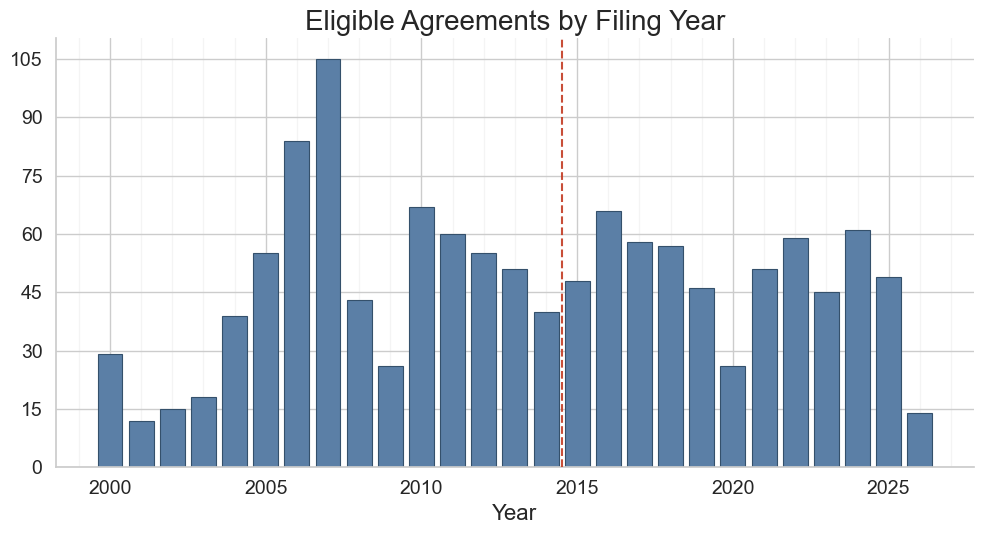

In [7]:
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.bar(
    sample_overview_df["year"],
    sample_overview_df["n_agreements"],
    width=0.8,
    color="#5b7fa6",
    edgecolor="#34506b",
    linewidth=0.8,
)
ax.set_title("Eligible Agreements by Filing Year", fontsize=20)
style_time_series_axis(ax, ylabel="")
ax.yaxis.set_major_locator(plt.matplotlib.ticker.MaxNLocator(integer=True))
ax.tick_params(axis="x", labelsize=14)
ax.tick_params(axis="y", labelsize=14)
fig.tight_layout()
save_figure(fig, "filtered_sample_agreements_by_year.png")
plt.show()


## 1. Have forum selection clauses remained nearly ubiquitous?

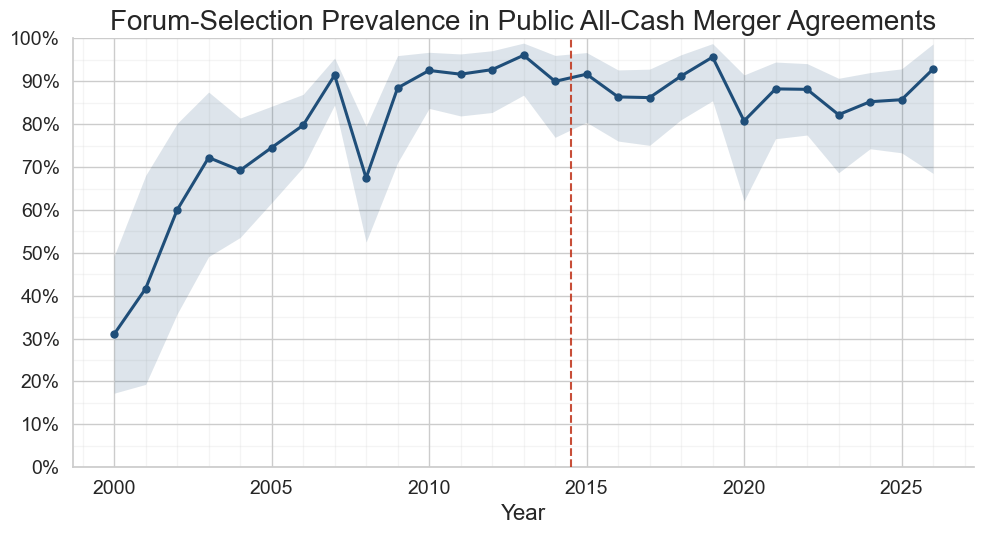

,year,n_agreements,k,share,lo,hi
0,2000,29,9,0.310345,0.172754,0.492305
1,2001,12,5,0.416667,0.193257,0.680493
2,2002,15,9,0.600000,0.357464,0.801758
3,2003,18,13,0.722222,0.491269,0.875004
4,2004,39,27,0.692308,0.535785,0.814342
5,2005,55,41,0.745455,0.616979,0.841880
6,2006,84,67,0.797619,0.699580,0.869627
7,2007,105,96,0.914286,0.845076,0.954251
8,2008,43,29,0.674419,0.525159,0.795069
9,2009,26,23,0.884615,0.710237,0.959968


In [8]:
yearly_totals = (
    agreements_filtered_df.groupby("year", as_index=False)
    .agg(n_agreements=("agreement_uuid", "nunique"))
)

yearly_with_clause = (
    forum_presence_df.groupby("year", as_index=False)
    .agg(k=("has_forum_clause", "sum"))
)

forum_prevalence_df = (
    yearly_totals.merge(yearly_with_clause, on="year", how="left")
    .fillna({"k": 0})
    .assign(k=lambda d: d["k"].astype(int))
    .sort_values("year")
)

lo, hi = wilson_ci(forum_prevalence_df["k"], forum_prevalence_df["n_agreements"])
forum_prevalence_df["share"] = forum_prevalence_df["k"] / forum_prevalence_df["n_agreements"]
forum_prevalence_df["lo"] = lo
forum_prevalence_df["hi"] = hi

fig, ax = plt.subplots(figsize=(10, 5.5))
plot_line_with_ci(
    ax,
    forum_prevalence_df,
    x="year",
    y="share",
    lo="lo",
    hi="hi",
    color="#1f4e79",
)
ax.set_title("Forum-Selection Prevalence in Public All-Cash Merger Agreements", fontsize=20)
ax.tick_params(axis="x", labelsize=14)
ax.tick_params(axis="y", labelsize=14)
style_time_series_axis(
    ax,
    ylabel="",
    percent=True,
    ylim=[0, 1],
)
fig.tight_layout()
save_figure(fig, "forum_clause_prevalence.png")
plt.show()

forum_prevalence_df

## 2. Have forum selection clauses continued to increase in length and complexity?

### State-pairing validation and clause-level prep

In [9]:
taxonomy_lookup = fetch_taxonomy_lookup(session, API_BASE_URL)

analysis_df = add_state_columns(analysis_df)
analysis_df = add_taxonomy_text_columns(analysis_df, taxonomy_lookup)
analysis_df["eligible"] = analysis_df.apply(
    lambda row: is_clause_family_eligible(row["standard_id"], row["states"], FORUM_CLAUSE_TYPE_ID),
    axis=1,
)
analysis_df["forum_only"] = analysis_df["standard_id"].apply(
    lambda value: is_clause_family_only(value, FORUM_CLAUSE_TYPE_ID)
)

df_for_eligible = select_one_clause_per_agreement(analysis_df.loc[analysis_df["eligible"]])
df_for_only = select_one_clause_per_agreement(analysis_df.loc[analysis_df["forum_only"]])

state_pairings_df = (
    df_for_eligible.assign(
        state_pairing=lambda d: d["states"].apply(
            lambda xs: " | ".join(xs) if isinstance(xs, list) else str(xs)
        ),
        n_states=lambda d: d["states"].apply(
            lambda xs: len([state for state in xs if state not in [None, "", "N/A"]])
            if isinstance(xs, list)
            else 0
        ),
    )
    .groupby(["state_pairing", "n_states"], as_index=False)
    .agg(
        n_clauses=("agreement_uuid", "size"),
        first_year=("year", "min"),
        last_year=("year", "max"),
    )
    .sort_values(["n_clauses", "state_pairing"], ascending=[False, True])
    .reset_index(drop=True)
)

multi_state_pairings_df = state_pairings_df.loc[state_pairings_df["n_states"] >= 2].copy()
high_count_pairing_outliers_df = multi_state_pairings_df.head(5).copy()
low_count_pairing_outliers_df = (
    multi_state_pairings_df.sort_values(["n_clauses", "state_pairing"], ascending=[True, True])
    .head(5)
    .copy()
)

print({
    "eligible_clauses": df_for_eligible.shape,
    "forum_only_clauses": df_for_only.shape,
    "distinct_state_pairings": int(state_pairings_df.shape[0]),
    "multi_state_pairings": int(multi_state_pairings_df.shape[0]),
})

display(state_pairings_df)
display(high_count_pairing_outliers_df)
display(low_count_pairing_outliers_df)


{'eligible_clauses': (894, 27), 'forum_only_clauses': (500, 27), 'distinct_state_pairings': 36, 'multi_state_pairings': 9}


,state_pairing,n_states,n_clauses,first_year,last_year
0,Delaware,1,611,2000,2026
1,Delaware | New York,2,114,2005,2026
2,New York,1,46,2000,2025
3,Maryland,1,42,2002,2025
4,N/A,0,9,2007,2024
5,Massachusetts,1,6,2005,2024
6,Ohio,1,6,2006,2025
7,California,1,5,2004,2017
8,Minnesota,1,5,2004,2022
9,Israel,1,4,2011,2021


,state_pairing,n_states,n_clauses,first_year,last_year
1,Delaware | New York,2,114,2005,2026
13,Nevada | New York,2,3,2012,2017
16,Maryland | New York,2,2,2014,2015
17,Massachusetts | New York,2,2,2005,2017
23,California | Delaware | New York,3,1,2017,2017


,state_pairing,n_states,n_clauses,first_year,last_year
23,California | Delaware | New York,3,1,2017,2017
25,Delaware | France,2,1,2016,2016
26,Delaware | Germany | New York,3,1,2019,2019
28,Minnesota | New York,2,1,2017,2017
29,New York | Pennsylvania,2,1,2012,2012


### Plot

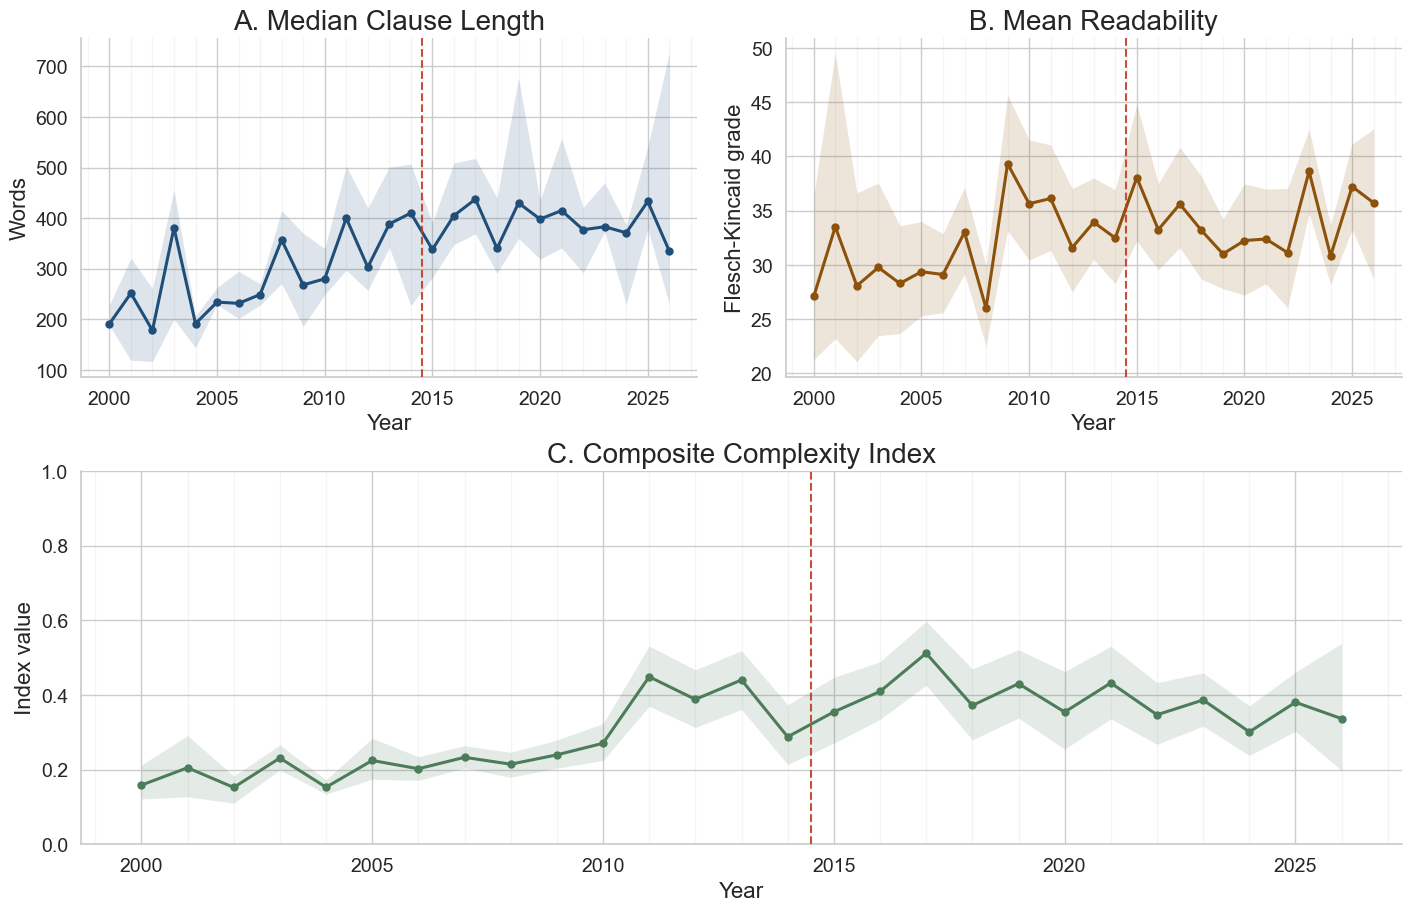

In [10]:
forum_text = xml_to_text(df_for_only["xml"])
df_for_only["word_count"] = forum_text.str.split().str.len()
df_for_only["readability"] = forum_text.map(
    lambda text: textstat.flesch_kincaid_grade(text) if text else np.nan
)
df_for_only["multiple_states"] = df_for_only["states"].apply(lambda xs: int(len(xs) > 1))
df_for_only["word_count_scaled"] = minmax_scale(np.log1p(df_for_only["word_count"]))
df_for_only["readability_scaled"] = minmax_scale(df_for_only["readability"])
df_for_only["complexity"] = df_for_only[[
    "word_count_scaled",
    "readability_scaled",
    "multiple_states",
]].mean(axis=1)

# Wilson intervals are appropriate for proportions; use bootstrap intervals for continuous clause metrics.
yearly_clause_counts = (
    df_for_only.groupby("year", as_index=False)
    .agg(n_clauses=("agreement_uuid", "size"))
    .sort_values("year")
)

word_count_summary = summarize_yearly_metric_with_bootstrap_ci(
    df_for_only,
    "word_count",
    np.median,
    "median_word_count",
    seed_offset=11,
)
readability_summary = summarize_yearly_metric_with_bootstrap_ci(
    df_for_only,
    "readability",
    np.mean,
    "mean_readability",
    seed_offset=23,
)
complexity_summary = summarize_yearly_metric_with_bootstrap_ci(
    df_for_only,
    "complexity",
    np.mean,
    "mean_complexity",
    seed_offset=37,
)

length_complexity_df = (
    yearly_clause_counts
    .merge(word_count_summary, on="year", how="left")
    .merge(readability_summary, on="year", how="left")
    .merge(complexity_summary, on="year", how="left")
)

fig = plt.figure(figsize=(14, 9), constrained_layout=True)
grid = fig.add_gridspec(2, 2, height_ratios=[1, 1.1])
ax_word = fig.add_subplot(grid[0, 0])
ax_readability = fig.add_subplot(grid[0, 1], sharex=ax_word)
ax_complexity = fig.add_subplot(grid[1, :], sharex=ax_word)

plot_line_with_ci(
    ax_word,
    length_complexity_df,
    x="year",
    y="median_word_count",
    lo="median_word_count_lo",
    hi="median_word_count_hi",
    color="#1f4e79",
)
ax_word.set_title("A. Median Clause Length", fontsize=20)
style_time_series_axis(ax_word, ylabel="Words")

ax_word.tick_params(axis="x", labelsize=14)
ax_word.tick_params(axis="y", labelsize=14)

plot_line_with_ci(
    ax_readability,
    length_complexity_df,
    x="year",
    y="mean_readability",
    lo="mean_readability_lo",
    hi="mean_readability_hi",
    color="#8c510a",
)
ax_readability.set_title("B. Mean Readability", fontsize=20)
style_time_series_axis(ax_readability, ylabel="Flesch-Kincaid grade")

ax_readability.tick_params(axis="x", labelsize=14)
ax_readability.tick_params(axis="y", labelsize=14)

plot_line_with_ci(
    ax_complexity,
    length_complexity_df,
    x="year",
    y="mean_complexity",
    lo="mean_complexity_lo",
    hi="mean_complexity_hi",
    color="#4c7c59",
)
ax_complexity.set_title("C. Composite Complexity Index", fontsize=20)
style_time_series_axis(ax_complexity, ylabel="Index value", ylim=(0, 1))

ax_complexity.tick_params(axis="x", labelsize=14)
ax_complexity.tick_params(axis="y", labelsize=14)

save_figure(fig, "forum_clause_length_complexity.png")
plt.show()


## 3. Has Delaware remained the dominant forum?

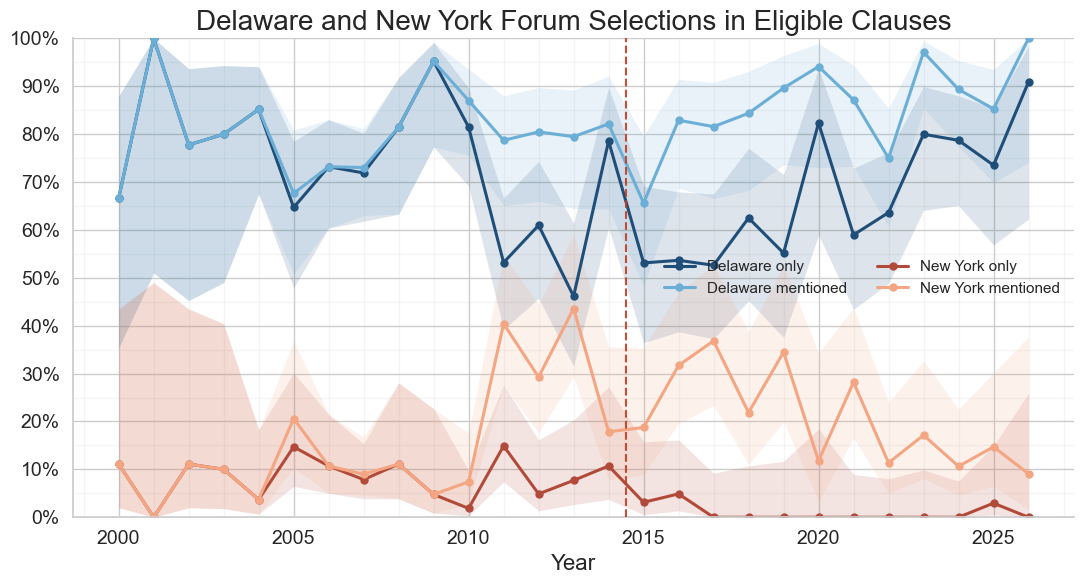

In [11]:
forum_state_yearly_df = (
    df_for_eligible.groupby("year", as_index=False)
    .agg(
        n_clauses=("agreement_uuid", "size"),
        delaware_only_k=("only_delaware", "sum"),
        new_york_only_k=("only_new_york", "sum"),
        delaware_mentions_k=("mentions_delaware", "sum"),
        new_york_mentions_k=("mentions_new_york", "sum"),
    )
    .sort_values("year")
)

forum_state_yearly_df["delaware_only_share"] = (
    forum_state_yearly_df["delaware_only_k"] / forum_state_yearly_df["n_clauses"]
)
forum_state_yearly_df["new_york_only_share"] = (
    forum_state_yearly_df["new_york_only_k"] / forum_state_yearly_df["n_clauses"]
)
forum_state_yearly_df["delaware_mentions_share"] = (
    forum_state_yearly_df["delaware_mentions_k"] / forum_state_yearly_df["n_clauses"]
)
forum_state_yearly_df["new_york_mentions_share"] = (
    forum_state_yearly_df["new_york_mentions_k"] / forum_state_yearly_df["n_clauses"]
)

de_only_lo, de_only_hi = wilson_ci(
    forum_state_yearly_df["delaware_only_k"],
    forum_state_yearly_df["n_clauses"],
)
de_mentions_lo, de_mentions_hi = wilson_ci(
    forum_state_yearly_df["delaware_mentions_k"],
    forum_state_yearly_df["n_clauses"],
)
ny_only_lo, ny_only_hi = wilson_ci(
    forum_state_yearly_df["new_york_only_k"],
    forum_state_yearly_df["n_clauses"],
)
ny_mentions_lo, ny_mentions_hi = wilson_ci(
    forum_state_yearly_df["new_york_mentions_k"],
    forum_state_yearly_df["n_clauses"],
)
forum_state_yearly_df["delaware_only_lo"] = de_only_lo
forum_state_yearly_df["delaware_only_hi"] = de_only_hi
forum_state_yearly_df["delaware_mentions_lo"] = de_mentions_lo
forum_state_yearly_df["delaware_mentions_hi"] = de_mentions_hi
forum_state_yearly_df["new_york_only_lo"] = ny_only_lo
forum_state_yearly_df["new_york_only_hi"] = ny_only_hi
forum_state_yearly_df["new_york_mentions_lo"] = ny_mentions_lo
forum_state_yearly_df["new_york_mentions_hi"] = ny_mentions_hi

fig, ax = plt.subplots(figsize=(11, 6))
plot_line_with_ci(
    ax,
    forum_state_yearly_df,
    x="year",
    y="delaware_only_share",
    lo="delaware_only_lo",
    hi="delaware_only_hi",
    label="Delaware only",
    color="#1f4e79",
)
plot_line_with_ci(
    ax,
    forum_state_yearly_df,
    x="year",
    y="delaware_mentions_share",
    lo="delaware_mentions_lo",
    hi="delaware_mentions_hi",
    label="Delaware mentioned",
    color="#6baed6",
)
plot_line_with_ci(
    ax,
    forum_state_yearly_df,
    x="year",
    y="new_york_only_share",
    lo="new_york_only_lo",
    hi="new_york_only_hi",
    label="New York only",
    color="#b24a3a",
)
plot_line_with_ci(
    ax,
    forum_state_yearly_df,
    x="year",
    y="new_york_mentions_share",
    lo="new_york_mentions_lo",
    hi="new_york_mentions_hi",
    label="New York mentioned",
    color="#f4a582",
)
ax.set_title("Delaware and New York Forum Selections in Eligible Clauses", fontsize=20)
style_time_series_axis(
    ax,
    ylabel="",
    percent=True,
    ylim=[0, 1],
)
ax.legend(frameon=False, ncol=2)

ax.tick_params(axis="x", labelsize=14)
ax.tick_params(axis="y", labelsize=14)

fig.tight_layout()
save_figure(fig, "forum_clause_delaware_new_york_shares.png")
plt.show()


In [12]:
forum_state_yearly_df

,year,n_clauses,delaware_only_k,new_york_only_k,delaware_mentions_k,new_york_mentions_k,delaware_only_share,new_york_only_share,delaware_mentions_share,new_york_mentions_share,delaware_only_lo,delaware_only_hi,delaware_mentions_lo,delaware_mentions_hi,new_york_only_lo,new_york_only_hi,new_york_mentions_lo,new_york_mentions_hi
0,2000,9,6,1,6,1,0.666667,0.111111,0.666667,0.111111,0.354197,0.879418,0.354197,0.879418,1.989037e-02,0.435006,0.019890,0.435006
1,2001,4,4,0,4,0,1.000000,0.000000,1.000000,0.000000,0.510100,1.000000,0.510100,1.000000,0.000000e+00,0.489900,0.000000,0.489900
2,2002,9,7,1,7,1,0.777778,0.111111,0.777778,0.111111,0.452583,0.936776,0.452583,0.936776,1.989037e-02,0.435006,0.019890,0.435006
3,2003,10,8,1,8,1,0.800000,0.100000,0.800000,0.100000,0.490157,0.943319,0.490157,0.943319,1.787575e-02,0.404156,0.017876,0.404156
4,2004,27,23,1,23,1,0.851852,0.037037,0.851852,0.037037,0.675209,0.940842,0.675209,0.940842,6.567977e-03,0.182839,0.006568,0.182839
5,2005,34,22,5,23,7,0.647059,0.147059,0.676471,0.205882,0.479137,0.785123,0.508426,0.808685,6.449346e-02,0.301284,0.103494,0.367987
6,2006,56,41,6,41,6,0.732143,0.107143,0.732143,0.107143,0.604052,0.830428,0.604052,0.830428,5.003867e-02,0.214687,0.050039,0.214687
7,2007,89,64,7,65,8,0.719101,0.078652,0.730337,0.089888,0.618164,0.801906,0.630032,0.811581,3.861933e-02,0.153553,0.046252,0.167463
8,2008,27,22,3,22,3,0.814815,0.111111,0.814815,0.111111,0.633009,0.918194,0.633009,0.918194,3.851965e-02,0.280582,0.038520,0.280582
9,2009,21,20,1,20,1,0.952381,0.047619,0.952381,0.047619,0.773302,0.991544,0.773302,0.991544,8.455769e-03,0.226698,0.008456,0.226698


In [13]:
df_for_eligible[
    df_for_eligible['mentions_delaware'] & 
    df_for_eligible['mentions_new_york']][['target', 'acquirer', 'year', 'agreement_uuid', 'section_uuid', 'xml']].values[53]

array(['Adams Resources & Energy, Inc.', 'Tres Energy LLC', 2024,
       '74d74a86-d060-5b57-92eb-23497b8fda4e',
       'c350e2e7-1f83-5139-9ceb-c48531063ce2',
       '\n        <text>The parties hereto agree that any suit, action or proceeding seeking to enforce any provision of, or based on any matter arising out of or in connection with, this Agreement or the transactions contemplated hereby (whether brought by any party or any of its Affiliates or against any party or any of its Affiliates) shall be brought in the Delaware Chancery Court or, if such court shall not have jurisdiction, any federal court located in the State of Delaware or other Delaware state court. Notwithstanding the foregoing, each of the parties hereto acknowledge and irrevocably agree that it will not bring or support, or permit any of its Affiliates to bring or support, any Action, whether in law or in equity, whether in contract or in tort or otherwise, against or involving the Financing Sources arising out of

## 4. How did forum-selection language change across 5-year windows?


In [14]:
PHRASE_SHIFT_PERIOD_WINDOWS = {
    "early": (2000, 2004),
    "early_middle": (2005, 2009),
    "middle": (2010, 2014),
    "late_middle": (2015, 2019),
    "late": (2020, 2024),
}
PHRASE_SHIFT_PERIOD_ORDER = ["early", "early_middle", "middle", "late_middle", "late"]
PHRASE_SHIFT_PERIOD_LABELS = {
    "early": "2000-2004",
    "early_middle": "2005-2009",
    "middle": "2010-2014",
    "late_middle": "2015-2019",
    "late": "2020-2024",
}
PHRASE_SHIFT_BUCKET_LABELS = {
    "only_delaware": "Delaware only",
    "mentions_delaware": "Delaware mentioned",
}
PHRASE_SHIFT_INTERIOR_PERIODS = ["early_middle", "middle", "late_middle"]
PHRASE_SHIFT_MIN_BUCKET_COUNT = 25
PHRASE_SHIFT_MIN_DOC_COUNT = 10
PHRASE_SHIFT_MIN_SHARE = 0.05
PHRASE_SHIFT_MIN_EFFECT = 0.10
PHRASE_SHIFT_FLAT_TOLERANCE = 0.05
PHRASE_SHIFT_SPIKE_GAP = 0.10
PHRASE_SHIFT_TOP_N = 15
PHRASE_SHIFT_EXAMPLE_TOP_N = 5
PHRASE_SHIFT_EXAMPLES_PER_PHRASE = 3
PHRASE_SHIFT_PLOT_PER_SIDE = 5
PHRASE_SHIFT_PLOT_COLORS = {
    "Addition": "#1f4e79",
    "Deletion": "#b24a3a",
}
MAX_N = 15

In [15]:
def phrase_shift_assign_period(year):
    for period, (start_year, end_year) in PHRASE_SHIFT_PERIOD_WINDOWS.items():
        if pd.notna(year) and start_year <= int(year) <= end_year:
            return period
    return None


def phrase_shift_clean_source_text(text):
    return re.sub(r"\s+", " ", text or "").strip()


def phrase_shift_strip_nontext_xml_fields(text):
    stripped_text = text or ""
    stripped_text = re.sub(
        r"<page>.*?</page>",
        " ",
        stripped_text,
        flags=re.IGNORECASE | re.DOTALL,
    )
    stripped_text = re.sub(
        r"<pageUUID>.*?</pageUUID>",
        " ",
        stripped_text,
        flags=re.IGNORECASE | re.DOTALL,
    )
    return stripped_text


def phrase_shift_normalize_text(text):
    normalized = phrase_shift_clean_source_text(text).lower()
    replacements = {
        r"\b(?:the )?court of chancery of the state of delaware\b": "delaware court of chancery",
        r"\b(?:the )?delaware court of chancery\b": "delaware court of chancery",
        r"\b(?:the )?united states district court for the district of delaware\b": "district of delaware",
        r"\bu\.?s\.? district court for the district of delaware\b": "district of delaware",
        r"\bfederal district court for the district of delaware\b": "district of delaware",
    }
    for pattern, replacement in replacements.items():
        normalized = re.sub(pattern, replacement, normalized)
    normalized = re.sub(r"[-/]+", " ", normalized)
    normalized = re.sub(r"[^a-z0-9\s']+", " ", normalized)
    normalized = re.sub(r"\s+", " ", normalized).strip()
    return normalized


def phrase_shift_extract_doc_phrases(text, min_n=2, max_n=MAX_N):
    tokens = [token for token in text.split() if token]
    doc_phrases = {}
    for n in range(min_n, max_n + 1):
        if len(tokens) < n:
            continue
        for start_idx in range(len(tokens) - n + 1):
            phrase = " ".join(tokens[start_idx : start_idx + n])
            doc_phrases[phrase] = n
    return doc_phrases


def phrase_shift_is_noisy_phrase(phrase):
    tokens = phrase.split()
    if not tokens:
        return True
    if not any(re.search(r"[a-z]", token) for token in tokens):
        return True
    numeric_like_tokens = sum(bool(re.fullmatch(r"[0-9]+(?:st|nd|rd|th)?", token)) for token in tokens)
    if numeric_like_tokens >= max(2, len(tokens) - 1):
        return True
    if re.fullmatch(r"(?:section|sections|article|articles) [a-z0-9 ]+", phrase):
        return True
    return False


def phrase_shift_pick_bucket(df, min_bucket_count=PHRASE_SHIFT_MIN_BUCKET_COUNT):
    bucket_counts = {
        "only_delaware": (
            df.loc[df["only_delaware"]]
            .groupby("period")["agreement_uuid"]
            .nunique()
            .reindex(PHRASE_SHIFT_PERIOD_ORDER, fill_value=0)
        ),
        "mentions_delaware": (
            df.loc[df["mentions_delaware"]]
            .groupby("period")["agreement_uuid"]
            .nunique()
            .reindex(PHRASE_SHIFT_PERIOD_ORDER, fill_value=0)
        ),
    }
    if (bucket_counts["only_delaware"] >= min_bucket_count).all():
        return "only_delaware", bucket_counts
    if (bucket_counts["mentions_delaware"] >= min_bucket_count).all():
        return "mentions_delaware", bucket_counts
    return "only_delaware", bucket_counts


def phrase_shift_classify_change(row):
    shares = [row[f"{period}_share"] for period in PHRASE_SHIFT_PERIOD_ORDER]
    step_deltas = [
        shares[idx + 1] - shares[idx]
        for idx in range(len(PHRASE_SHIFT_PERIOD_ORDER) - 1)
    ]
    net_delta = row["delta_early_to_late"]
    max_interior_share = max(row[f"{period}_share"] for period in PHRASE_SHIFT_INTERIOR_PERIODS)

    if net_delta >= PHRASE_SHIFT_MIN_EFFECT and all(delta >= -PHRASE_SHIFT_FLAT_TOLERANCE for delta in step_deltas):
        return "steady increase"
    if net_delta <= -PHRASE_SHIFT_MIN_EFFECT and all(delta <= PHRASE_SHIFT_FLAT_TOLERANCE for delta in step_deltas):
        return "steady decrease"
    if (
        max(abs(delta) for delta in step_deltas[:-1]) < PHRASE_SHIFT_FLAT_TOLERANCE
        and step_deltas[-1] >= PHRASE_SHIFT_MIN_EFFECT
    ):
        return "late jump"
    if (
        max_interior_share >= row["early_share"] + PHRASE_SHIFT_SPIKE_GAP
        and max_interior_share >= row["late_share"] + PHRASE_SHIFT_SPIKE_GAP
    ):
        return "mid-period spike"
    return "mixed"


def phrase_shift_phrase_is_strict_subphrase(short_phrase, long_phrase):
    """True if short_phrase is a shorter consecutive token run inside long_phrase."""
    short_n = len(short_phrase.split())
    long_n = len(long_phrase.split())
    if short_n == 0 or long_n == 0 or short_n >= long_n:
        return False
    return f" {short_phrase} " in f" {long_phrase} "


def phrase_shift_collapse_overlaps(df, top_n=PHRASE_SHIFT_TOP_N):
    """Keep top_n rows in rank order, dropping n-grams that nest inside another kept phrase.

    Shared by §4 (full normalized text) and §5 (stopword-stripped substantive text). When a longer
    phrase appears later in the ranked list, shorter kept phrases that are only fragments of it
    are removed so the table shows maximal spans (e.g. one row for \"relating to this agreement or the\"
    instead of \"or the\", \"this agreement or the\", …).
    """
    kept_rows = []
    for record in df.to_dict("records"):
        phrase = record["phrase"]
        kept_rows = [
            kept
            for kept in kept_rows
            if not phrase_shift_phrase_is_strict_subphrase(kept["phrase"], phrase)
        ]
        if any(
            phrase_shift_phrase_is_strict_subphrase(phrase, kept["phrase"])
            for kept in kept_rows
        ):
            continue
        kept_rows.append(record)
        if len(kept_rows) >= top_n:
            break
    return pd.DataFrame(kept_rows)


def phrase_shift_pick_example_period(row):
    if row["change_shape"] == "mid-period spike":
        return max(
            PHRASE_SHIFT_INTERIOR_PERIODS,
            key=lambda period: row[f"{period}_share"],
        )
    return "late" if row["delta_early_to_late"] >= 0 else "early"


def phrase_shift_extract_snippet(source_text, phrase, width=180):
    haystack = phrase_shift_clean_source_text(source_text)
    lowered_haystack = haystack.lower()
    lowered_phrase = phrase.lower()
    start_idx = lowered_haystack.find(lowered_phrase)
    if start_idx == -1:
        first_token = lowered_phrase.split()[0]
        start_idx = lowered_haystack.find(first_token)
    if start_idx == -1:
        snippet = haystack[:width].strip()
        return snippet + ("..." if len(haystack) > width else "")

    end_idx = start_idx + len(lowered_phrase)
    window_start = max(0, start_idx - width // 2)
    window_end = min(len(haystack), end_idx + width // 2)
    snippet = haystack[window_start:window_end].strip()
    if window_start > 0:
        snippet = "..." + snippet
    if window_end < len(haystack):
        snippet = snippet + "..."
    return snippet

In [16]:
phrase_shift_base_df = df_for_only.copy()
phrase_shift_base_df["plain_text"] = xml_to_text(
    phrase_shift_base_df["xml"].map(phrase_shift_strip_nontext_xml_fields)
)
phrase_shift_base_df["source_text"] = phrase_shift_base_df["plain_text"].map(phrase_shift_clean_source_text)
phrase_shift_base_df["normalized_text"] = phrase_shift_base_df["plain_text"].map(phrase_shift_normalize_text)
phrase_shift_base_df["period"] = phrase_shift_base_df["year"].map(phrase_shift_assign_period)
phrase_shift_base_df = phrase_shift_base_df.loc[
    phrase_shift_base_df["period"].isin(PHRASE_SHIFT_PERIOD_ORDER)
    & phrase_shift_base_df["normalized_text"].ne("")
].copy()

if phrase_shift_base_df["agreement_uuid"].duplicated().any():
    raise RuntimeError("Phrase-shift section expected one clause per agreement in df_for_only.")

phrase_shift_bucket_field, phrase_shift_bucket_counts = phrase_shift_pick_bucket(
    phrase_shift_base_df
)
phrase_shift_bucket_description = PHRASE_SHIFT_BUCKET_LABELS[phrase_shift_bucket_field]
phrase_shift_base_df = phrase_shift_base_df.loc[
    phrase_shift_base_df[phrase_shift_bucket_field]
].copy()

phrase_shift_period_counts = (
    phrase_shift_base_df.groupby("period")["agreement_uuid"]
    .nunique()
    .reindex(PHRASE_SHIFT_PERIOD_ORDER, fill_value=0)
)
if (phrase_shift_period_counts == 0).any():
    raise RuntimeError(
        "Phrase-shift section needs at least one clause in each period after bucket filtering."
    )

print({
    "bucket": phrase_shift_bucket_description,
    "bucket_field": phrase_shift_bucket_field,
    "bucket_candidate_counts": {
        name: {period: int(counts[period]) for period in PHRASE_SHIFT_PERIOD_ORDER}
        for name, counts in phrase_shift_bucket_counts.items()
    },
    "analysis_counts": {
        period: int(phrase_shift_period_counts[period])
        for period in PHRASE_SHIFT_PERIOD_ORDER
    },
    "unique_agreements": int(phrase_shift_base_df["agreement_uuid"].nunique()),
})
if phrase_shift_bucket_field != "only_delaware":
    print(
        "Expanded from Delaware-only to Delaware-mentioned clauses because the narrower bucket was below the stability threshold."
    )
elif (phrase_shift_period_counts < PHRASE_SHIFT_MIN_BUCKET_COUNT).any():
    print(
        "Using Delaware-only clauses despite thin period counts because the broader Delaware-mentioned bucket was also below the stability threshold."
    )

phrase_shift_records = []
for row in phrase_shift_base_df[["agreement_uuid", "period", "normalized_text"]].itertuples(index=False):
    for phrase, n_value in phrase_shift_extract_doc_phrases(row.normalized_text).items():
        phrase_shift_records.append(
            {
                "phrase": phrase,
                "n": n_value,
                "period": row.period,
                "agreement_uuid": row.agreement_uuid,
            }
        )

if not phrase_shift_records:
    raise RuntimeError("Phrase-shift section did not generate any n-gram features.")

phrase_shift_doc_phrase_df = pd.DataFrame(phrase_shift_records)
phrase_shift_phrase_df = (
    phrase_shift_doc_phrase_df.groupby(["phrase", "n", "period"], as_index=False)
    .agg(doc_n=("agreement_uuid", "nunique"))
    .pivot_table(index=["phrase", "n"], columns="period", values="doc_n", fill_value=0)
    .reset_index()
)
phrase_shift_phrase_df.columns.name = None
for period in PHRASE_SHIFT_PERIOD_ORDER:
    if period not in phrase_shift_phrase_df.columns:
        phrase_shift_phrase_df[period] = 0

for period in PHRASE_SHIFT_PERIOD_ORDER:
    phrase_shift_phrase_df[f"{period}_doc_n"] = phrase_shift_phrase_df[period].astype(int)
    phrase_shift_phrase_df[f"{period}_share"] = (
        phrase_shift_phrase_df[f"{period}_doc_n"] / phrase_shift_period_counts[period]
    )

phrase_shift_phrase_df = phrase_shift_phrase_df.drop(columns=PHRASE_SHIFT_PERIOD_ORDER)
phrase_shift_phrase_df["phrase_length"] = phrase_shift_phrase_df["phrase"].str.len()
for idx in range(len(PHRASE_SHIFT_PERIOD_ORDER) - 1):
    left_period = PHRASE_SHIFT_PERIOD_ORDER[idx]
    right_period = PHRASE_SHIFT_PERIOD_ORDER[idx + 1]
    phrase_shift_phrase_df[f"delta_{left_period}_to_{right_period}"] = (
        phrase_shift_phrase_df[f"{right_period}_share"] - phrase_shift_phrase_df[f"{left_period}_share"]
    )
phrase_shift_phrase_df["delta_early_to_late"] = (
    phrase_shift_phrase_df["late_share"] - phrase_shift_phrase_df["early_share"]
)

phrase_shift_phrase_df = phrase_shift_phrase_df.loc[
    phrase_shift_phrase_df[[f"{period}_doc_n" for period in PHRASE_SHIFT_PERIOD_ORDER]].max(axis=1)
    >= PHRASE_SHIFT_MIN_DOC_COUNT
].copy()
phrase_shift_phrase_df = phrase_shift_phrase_df.loc[
    phrase_shift_phrase_df[[f"{period}_share" for period in PHRASE_SHIFT_PERIOD_ORDER]].max(axis=1)
    >= PHRASE_SHIFT_MIN_SHARE
].copy()
phrase_shift_phrase_df = phrase_shift_phrase_df.loc[
    phrase_shift_phrase_df["phrase"].map(lambda phrase: not phrase_shift_is_noisy_phrase(phrase))
].copy()
phrase_shift_phrase_df = phrase_shift_phrase_df.loc[
    phrase_shift_phrase_df["delta_early_to_late"].abs() >= PHRASE_SHIFT_MIN_EFFECT
].copy()
phrase_shift_phrase_df["change_shape"] = phrase_shift_phrase_df.apply(
    phrase_shift_classify_change,
    axis=1,
)

phrase_shift_additions_df = phrase_shift_phrase_df.sort_values(
    ["delta_early_to_late", "n", "phrase_length", "late_share", "phrase"],
    ascending=[False, False, False, False, True],
).reset_index(drop=True)
# Same maximal subphrase dedup as §5 (phrase_shift_collapse_overlaps).
phrase_shift_additions_df = phrase_shift_collapse_overlaps(
    phrase_shift_additions_df,
    top_n=PHRASE_SHIFT_TOP_N,
)

phrase_shift_deletions_df = phrase_shift_phrase_df.sort_values(
    ["delta_early_to_late", "n", "phrase_length", "early_share", "phrase"],
    ascending=[True, False, False, False, True],
).reset_index(drop=True)
phrase_shift_deletions_df = phrase_shift_collapse_overlaps(
    phrase_shift_deletions_df,
    top_n=PHRASE_SHIFT_TOP_N,
)

phrase_shift_example_targets_df = pd.concat(
    [
        phrase_shift_additions_df.head(PHRASE_SHIFT_EXAMPLE_TOP_N).assign(direction="Addition"),
        phrase_shift_deletions_df.head(PHRASE_SHIFT_EXAMPLE_TOP_N).assign(direction="Deletion"),
    ],
    ignore_index=True,
)

phrase_shift_example_records = []
for row in phrase_shift_example_targets_df.to_dict("records"):
    example_period = phrase_shift_pick_example_period(row)
    example_matches_df = phrase_shift_base_df.loc[
        phrase_shift_base_df["period"].eq(example_period)
        & phrase_shift_base_df["normalized_text"].map(
            lambda text, target=row["phrase"]: f" {target} " in f" {text} "
        )
    ].sort_values(["year", "agreement_uuid"])

    for example_row in example_matches_df.head(PHRASE_SHIFT_EXAMPLES_PER_PHRASE).itertuples(index=False):
        phrase_shift_example_records.append(
            {
                "direction": row["direction"],
                "phrase": row["phrase"],
                "example_period": example_period,
                "agreement_uuid": example_row.agreement_uuid,
                "year": int(example_row.year),
                "period": example_row.period,
                "snippet": phrase_shift_extract_snippet(example_row.source_text, row["phrase"]),
            }
        )

phrase_shift_examples_df = pd.DataFrame(phrase_shift_example_records)

phrase_shift_display_columns = [
    "phrase",
    "n",
    "early_doc_n",
    "early_middle_doc_n",
    "middle_doc_n",
    "late_middle_doc_n",
    "late_doc_n",
    "early_share",
    "early_middle_share",
    "middle_share",
    "late_middle_share",
    "late_share",
    "delta_early_to_late",
    "change_shape",
]

display(
    phrase_shift_additions_df.loc[:, phrase_shift_display_columns]
    .head(PHRASE_SHIFT_TOP_N)
    .style.format(
        {
            "early_share": "{:.1%}",
            "early_middle_share": "{:.1%}",
            "middle_share": "{:.1%}",
            "late_middle_share": "{:.1%}",
            "late_share": "{:.1%}",
            "delta_early_to_late": "{:+.1%}",
        }
    )
)

display(
    phrase_shift_deletions_df.loc[:, phrase_shift_display_columns]
    .head(PHRASE_SHIFT_TOP_N)
    .style.format(
        {
            "early_share": "{:.1%}",
            "early_middle_share": "{:.1%}",
            "middle_share": "{:.1%}",
            "late_middle_share": "{:.1%}",
            "late_share": "{:.1%}",
            "delta_early_to_late": "{:+.1%}",
        }
    )
)

if phrase_shift_examples_df.empty:
    print("No snippet examples were found for the displayed phrase shifts.")
else:
    display(phrase_shift_examples_df)

{'bucket': 'Delaware only', 'bucket_field': 'only_delaware', 'bucket_candidate_counts': {'only_delaware': {'early': 31, 'early_middle': 73, 'middle': 61, 'late_middle': 49, 'late': 59}, 'mentions_delaware': {'early': 31, 'early_middle': 75, 'middle': 98, 'late_middle': 93, 'late': 88}}, 'analysis_counts': {'early': 31, 'early_middle': 73, 'middle': 61, 'late_middle': 49, 'late': 59}, 'unique_agreements': 273}


,phrase,n,early_doc_n,early_middle_doc_n,middle_doc_n,late_middle_doc_n,late_doc_n,early_share,early_middle_share,middle_share,late_middle_share,late_share,delta_early_to_late,change_shape
0,delaware court of chancery,4,7,40,42,33,47,22.6%,54.8%,68.9%,67.3%,79.7%,+57.1%,steady increase
1,relating to this agreement or the transactions,7,0,12,15,21,28,0.0%,16.4%,24.6%,42.9%,47.5%,+47.5%,steady increase
2,of its,2,0,21,29,11,26,0.0%,28.8%,47.5%,22.4%,44.1%,+44.1%,mixed
3,and agrees not to,4,7,31,31,24,38,22.6%,42.5%,50.8%,49.0%,64.4%,+41.8%,steady increase
4,in such,2,6,36,35,26,36,19.4%,49.3%,57.4%,53.1%,61.0%,+41.7%,steady increase
5,permitted by applicable law,4,3,10,22,15,30,9.7%,13.7%,36.1%,30.6%,50.8%,+41.2%,mixed
6,in connection with this agreement,5,7,13,23,16,37,22.6%,17.8%,37.7%,32.7%,62.7%,+40.1%,mixed
7,of this agreement,3,6,36,44,30,35,19.4%,49.3%,72.1%,61.2%,59.3%,+40.0%,mid-period spike
8,in accordance with,3,2,17,22,15,27,6.5%,23.3%,36.1%,30.6%,45.8%,+39.3%,mixed
9,the venue of,3,10,25,31,23,42,32.3%,34.2%,50.8%,46.9%,71.2%,+38.9%,steady increase


,phrase,n,early_doc_n,early_middle_doc_n,middle_doc_n,late_middle_doc_n,late_doc_n,early_share,early_middle_share,middle_share,late_middle_share,late_share,delta_early_to_late,change_shape
0,district of delaware,3,13,17,6,8,5,41.9%,23.3%,9.8%,16.3%,8.5%,-33.5%,mixed
1,the personal,2,15,30,20,13,11,48.4%,41.1%,32.8%,26.5%,18.6%,-29.7%,steady decrease
2,action or proceeding arising out of or relating to this agreement,11,10,11,4,8,3,32.3%,15.1%,6.6%,16.3%,5.1%,-27.2%,mixed
3,any delaware state court,4,8,13,11,2,0,25.8%,17.8%,18.0%,4.1%,0.0%,-25.8%,steady decrease
4,this agreement in,3,10,31,23,9,5,32.3%,42.5%,37.7%,18.4%,8.5%,-23.8%,mid-period spike
5,action or proceeding may be,5,11,13,13,10,7,35.5%,17.8%,21.3%,20.4%,11.9%,-23.6%,steady decrease
6,any such court and,4,8,15,9,3,2,25.8%,20.5%,14.8%,6.1%,3.4%,-22.4%,steady decrease
7,courts of,2,10,11,8,14,6,32.3%,15.1%,13.1%,28.6%,10.2%,-22.1%,mixed
8,and each of,3,14,17,17,22,14,45.2%,23.3%,27.9%,44.9%,23.7%,-21.4%,mixed
9,jurisdiction of any,3,16,38,26,16,18,51.6%,52.1%,42.6%,32.7%,30.5%,-21.1%,steady decrease


,direction,phrase,example_period,agreement_uuid,year,period,snippet
0,Addition,delaware court of chancery,late,0ccdac8a-f969-5e68-aaab-8f42829710a6,2020,late,...tion or proceeding to the exclusive jurisdi...
1,Addition,delaware court of chancery,late,33afdf7b-be11-5b18-bf61-1e12193a0fa5,2020,late,...r its Affiliates shall be brought and deter...
2,Addition,delaware court of chancery,late,6b354ee6-e15d-5432-8cae-95ee1c886db3,2020,late,"...connection with, this Agreement or the Cont..."
3,Addition,relating to this agreement or the transactions,late,0ccdac8a-f969-5e68-aaab-8f42829710a6,2020,late,...d agrees not to plead or claim the same; an...
4,Addition,relating to this agreement or the transactions,late,33afdf7b-be11-5b18-bf61-1e12193a0fa5,2020,late,"...or as a defense, counterclaim or otherwise,..."
5,Addition,relating to this agreement or the transactions,late,c42b6a9e-9d0d-54bb-b17d-d263bfa2e64d,2020,late,...d agrees not to plead or claim the same; an...
6,Addition,of its,late,0ccdac8a-f969-5e68-aaab-8f42829710a6,2020,late,...proceeding relating to the transactions con...
7,Addition,of its,late,c42b6a9e-9d0d-54bb-b17d-d263bfa2e64d,2020,late,...proceeding relating to the transactions con...
8,Addition,of its,late,15afec7b-0f58-5af9-899b-41ce98e7732b,2021,late,...is Agreement or the transactions contemplat...
9,Addition,and agrees not to,late,0ccdac8a-f969-5e68-aaab-8f42829710a6,2020,late,...in any such court or that such action or pr...


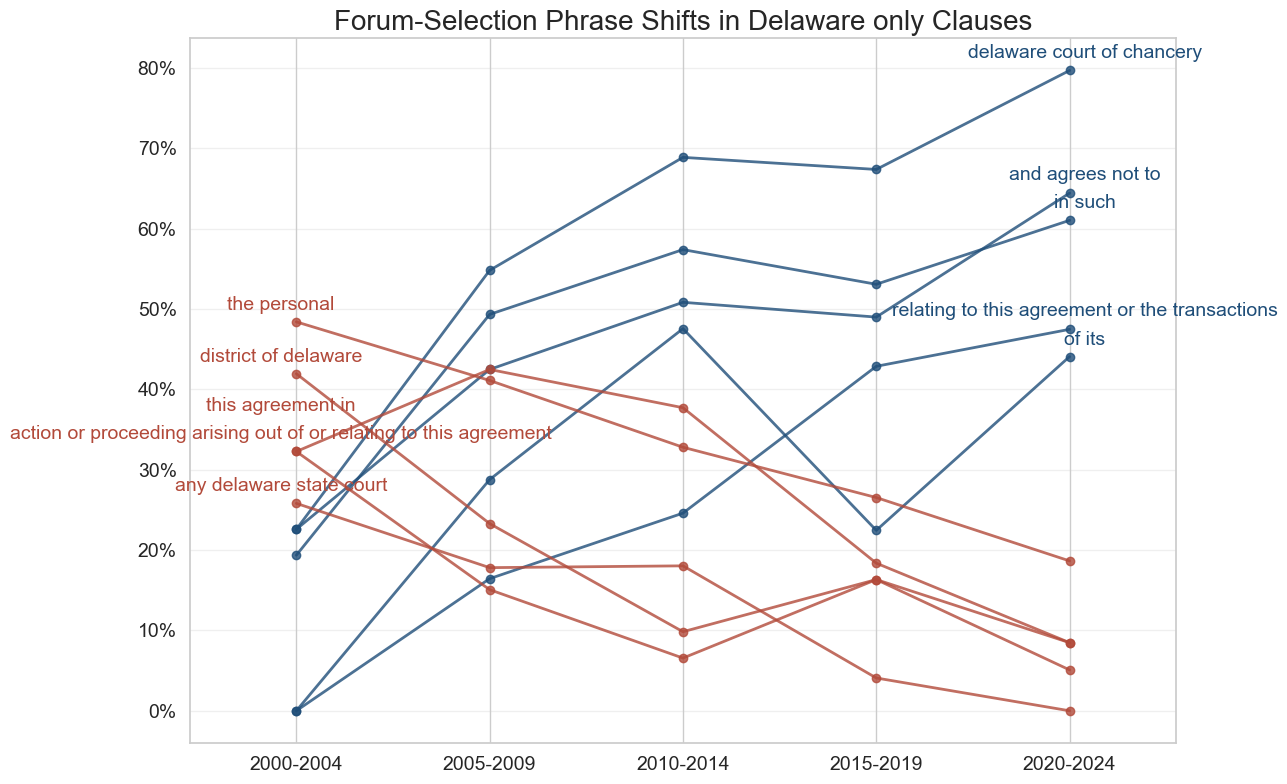

In [17]:
phrase_shift_plot_df = pd.concat(
    [
        phrase_shift_additions_df.head(PHRASE_SHIFT_PLOT_PER_SIDE).assign(direction="Addition"),
        phrase_shift_deletions_df.head(PHRASE_SHIFT_PLOT_PER_SIDE).assign(direction="Deletion"),
    ],
    ignore_index=True,
)

def phrase_shift_spread_label_positions(label_rows, min_gap=0.035):
    adjusted_rows = []
    last_y = None
    for label_row in sorted(label_rows, key=lambda item: item["label_y"]):
        adjusted_y = label_row["label_y"]
        if last_y is not None and adjusted_y - last_y < min_gap:
            adjusted_y = last_y + min_gap
        adjusted_rows.append({**label_row, "adjusted_y": adjusted_y})
        last_y = adjusted_y
    return adjusted_rows

fig, ax = plt.subplots(figsize=(13, 8))
plot_records = phrase_shift_plot_df.to_dict("records")
label_rows = []
for row in plot_records:
    shares = [row[f"{period}_share"] for period in PHRASE_SHIFT_PERIOD_ORDER]
    x_values = list(range(len(PHRASE_SHIFT_PERIOD_ORDER)))
    color = PHRASE_SHIFT_PLOT_COLORS[row["direction"]]
    ax.plot(x_values, shares, marker="o", linewidth=2, alpha=0.8, color=color)
    label_rows.append(
        {
            "phrase": row["phrase"],
            "direction": row["direction"],
            "color": color,
            "label_x": x_values[-1] + 0.08 if row["direction"] == "Addition" else x_values[0] - 0.08,
            "label_y": shares[-1] if row["direction"] == "Addition" else shares[0],
        }
    )

adjusted_label_rows = []
for direction in ["Deletion", "Addition"]:
    adjusted_label_rows.extend(
        phrase_shift_spread_label_positions(
            [label_row for label_row in label_rows if label_row["direction"] == direction]
        )
    )

for label_row in adjusted_label_rows:
    ax.text(
        label_row["label_x"],
        label_row["adjusted_y"]+0.01,
        label_row["phrase"],
        ha="center",#if label_row["direction"] == "Addition" else "right",
        va="bottom",
        fontsize=14,
        color=label_row["color"],
    )

ax.set_xticks(range(len(PHRASE_SHIFT_PERIOD_ORDER)))
ax.set_xticklabels([PHRASE_SHIFT_PERIOD_LABELS[period] for period in PHRASE_SHIFT_PERIOD_ORDER])
ax.set_xlim(-0.55, len(PHRASE_SHIFT_PERIOD_ORDER) - 1 + 0.55)
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_title(
    f"Forum-Selection Phrase Shifts in {phrase_shift_bucket_description} Clauses",
    fontsize=20
)

ax.tick_params(axis="x", labelsize=14)
ax.tick_params(axis="y", labelsize=14)

ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
save_figure(fig, "forum_clause_phrase_shift_five_periods.png")
plt.show()

## 5. Which substantive phrases changed after removing stop words?


{'bucket': 'Delaware only', 'analysis_counts': {'early': 31, 'early_middle': 73, 'middle': 61, 'late_middle': 49, 'late': 59}, 'stopwords_removed': True, 'min_n_without_stopwords': 3}


,phrase,n,early_doc_n,early_middle_doc_n,middle_doc_n,late_middle_doc_n,late_doc_n,early_share,early_middle_share,middle_share,late_middle_share,late_share,delta_early_to_late,change_shape
0,relating agreement transactions,3,1,12,15,21,28,3.2%,16.4%,24.6%,42.9%,47.5%,+44.2%,steady increase
1,proceeding brought inconvenient,3,0,1,10,6,21,0.0%,1.4%,16.4%,12.2%,35.6%,+35.6%,steady increase
2,waives any objection,3,2,6,13,9,24,6.5%,8.2%,21.3%,18.4%,40.7%,+34.2%,steady increase
3,jurisdiction delaware court chancery,4,4,16,24,20,27,12.9%,21.9%,39.3%,40.8%,45.8%,+32.9%,steady increase
4,agrees not plead claim,4,1,11,16,8,21,3.2%,15.1%,26.2%,16.3%,35.6%,+32.4%,mixed
5,federal court within state delaware,5,0,7,9,14,18,0.0%,9.6%,14.8%,28.6%,30.5%,+30.5%,steady increase
6,accept jurisdiction particular matter,4,0,8,9,16,18,0.0%,11.0%,14.8%,32.7%,30.5%,+30.5%,steady increase
7,jurisdiction particular matter any,4,0,8,12,14,18,0.0%,11.0%,19.7%,28.6%,30.5%,+30.5%,steady increase
8,brought tried determined,3,0,0,8,3,18,0.0%,0.0%,13.1%,6.1%,30.5%,+30.5%,mixed
9,not bring any,3,8,31,29,17,33,25.8%,42.5%,47.5%,34.7%,55.9%,+30.1%,mixed


,phrase,n,early_doc_n,early_middle_doc_n,middle_doc_n,late_middle_doc_n,late_doc_n,early_share,early_middle_share,middle_share,late_middle_share,late_share,delta_early_to_late,change_shape
0,any delaware state court,4,9,15,12,2,1,29.0%,20.5%,19.7%,4.1%,1.7%,-27.3%,steady decrease
1,any objection may now hereafter laying venue any suit action proceeding,11,10,9,10,8,5,32.3%,12.3%,16.4%,16.3%,8.5%,-23.8%,steady decrease
2,action proceeding may,3,11,13,14,11,9,35.5%,17.8%,23.0%,22.4%,15.3%,-20.2%,mixed
3,agrees all claims respect action,5,7,10,8,5,2,22.6%,13.7%,13.1%,10.2%,3.4%,-19.2%,steady decrease
4,may heard determined,3,7,12,8,10,2,22.6%,16.4%,13.1%,20.4%,3.4%,-19.2%,mixed
5,delaware any action,3,6,12,7,1,1,19.4%,16.4%,11.5%,2.0%,1.7%,-17.7%,steady decrease
6,any action proceeding arising relating agreement,6,7,11,2,6,3,22.6%,15.1%,3.3%,12.2%,5.1%,-17.5%,mixed
7,consents submit personal jurisdiction,4,7,14,8,6,3,22.6%,19.2%,13.1%,12.2%,5.1%,-17.5%,steady decrease
8,state delaware any,3,11,16,18,12,11,35.5%,21.9%,29.5%,24.5%,18.6%,-16.8%,mixed
9,defense inconvenient forum maintenance,4,6,14,8,7,2,19.4%,19.2%,13.1%,14.3%,3.4%,-16.0%,steady decrease


,direction,phrase,example_period,agreement_uuid,year,period,snippet
0,Addition,relating agreement transactions,late,0ccdac8a-f969-5e68-aaab-8f42829710a6,2020,late,...he service of the summons and complaint and...
1,Addition,relating agreement transactions,late,33afdf7b-be11-5b18-bf61-1e12193a0fa5,2020,late,...h of the parties irrevocably agrees that an...
2,Addition,relating agreement transactions,late,c42b6a9e-9d0d-54bb-b17d-d263bfa2e64d,2020,late,...he service of the summons and complaint and...
3,Addition,proceeding brought inconvenient,late,0ccdac8a-f969-5e68-aaab-8f42829710a6,2020,late,...nsents to the service of the summons and co...
4,Addition,proceeding brought inconvenient,late,c42b6a9e-9d0d-54bb-b17d-d263bfa2e64d,2020,late,...nsents to the service of the summons and co...
5,Addition,proceeding brought inconvenient,late,2443d5a9-afc9-5ac3-b853-5e1390cb347d,2021,late,The parties hereto agree that any Proceeding s...
6,Addition,waives any objection,late,0ccdac8a-f969-5e68-aaab-8f42829710a6,2020,late,...eral or other state court sitting in New Ca...
7,Addition,waives any objection,late,6b354ee6-e15d-5432-8cae-95ee1c886db3,2020,late,...iction of such court (and of the appropriat...
8,Addition,waives any objection,late,c42b6a9e-9d0d-54bb-b17d-d263bfa2e64d,2020,late,...eral or other state court sitting in New Ca...
9,Addition,jurisdiction delaware court chancery,late,0ccdac8a-f969-5e68-aaab-8f42829710a6,2020,late,...submits itself and its properties and asset...


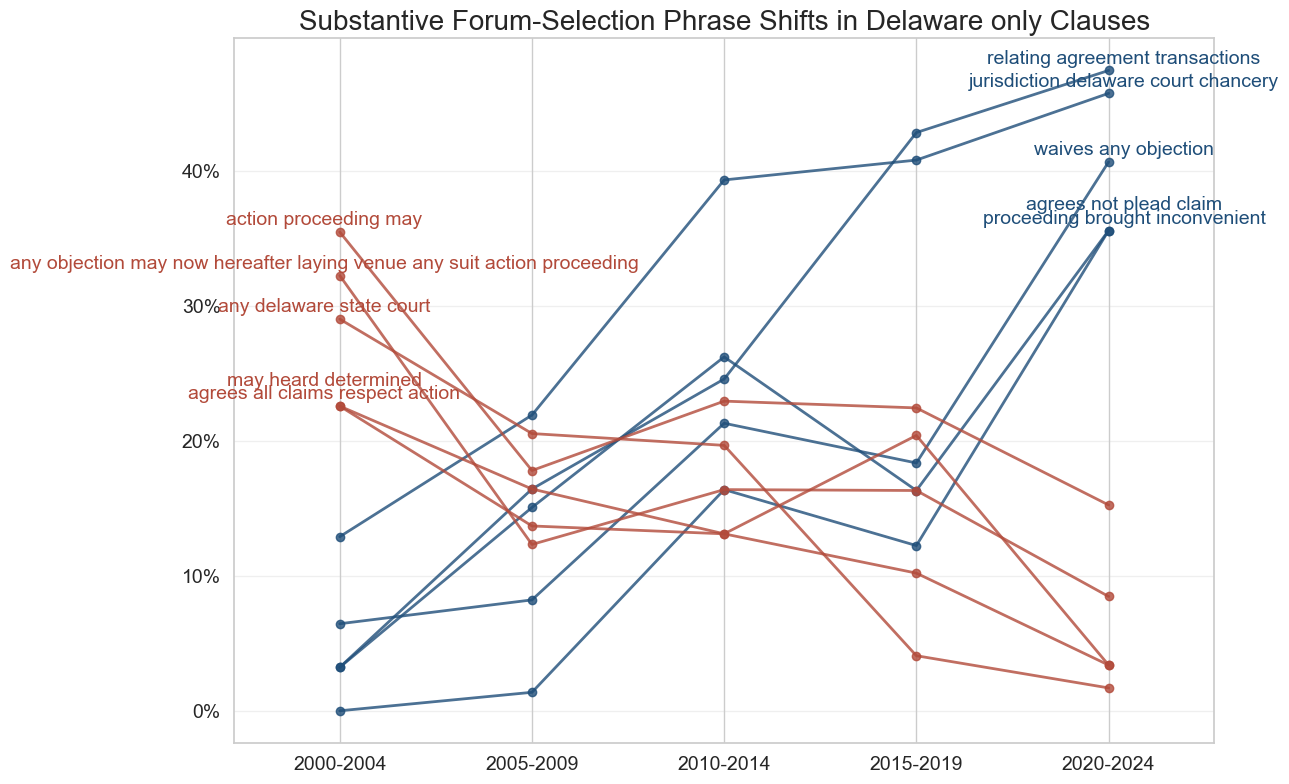

In [18]:
PHRASE_SHIFT_SUBSTANTIVE_STOPWORDS = {
    "a", "an", "and", "are", "as", "at", "be", "because", "been", "before",
    "being", "between", "both", "but", "by", "for", "from", "had", "has",
    "have", "having", "he", "her", "here", "hers", "herself", "him", "himself",
    "his", "if", "in", "into", "is", "it", "its", "itself", "me", "more",
    "most", "my", "myself", "of", "on", "once", "only", "or", "other",
    "our", "ours", "ourselves", "out", "over", "own", "same", "she", "so",
    "some", "such", "than", "that", "the", "their", "theirs", "them",
    "themselves", "then", "there", "these", "they", "this", "those", "through",
    "to", "too", "under", "until", "up", "very", "was", "we", "were", "what",
    "when", "where", "which", "while", "who", "whom", "why", "with", "you",
    "your", "yours", "yourself", "yourselves",
}
PHRASE_SHIFT_SUBSTANTIVE_MIN_N = 3
PHRASE_SHIFT_SUBSTANTIVE_TOP_N = PHRASE_SHIFT_TOP_N
PHRASE_SHIFT_SUBSTANTIVE_PLOT_PER_SIDE = PHRASE_SHIFT_PLOT_PER_SIDE
PHRASE_SHIFT_SUBSTANTIVE_EXAMPLE_TOP_N = PHRASE_SHIFT_EXAMPLE_TOP_N
PHRASE_SHIFT_SUBSTANTIVE_EXAMPLES_PER_PHRASE = PHRASE_SHIFT_EXAMPLES_PER_PHRASE


def phrase_shift_remove_stopwords(text, stopwords=PHRASE_SHIFT_SUBSTANTIVE_STOPWORDS):
    tokens = [token for token in text.split() if token and token not in stopwords]
    return " ".join(tokens)


phrase_shift_substantive_base_df = phrase_shift_base_df.copy()
phrase_shift_substantive_base_df["substantive_text"] = phrase_shift_substantive_base_df[
    "normalized_text"
].map(phrase_shift_remove_stopwords)
phrase_shift_substantive_base_df = phrase_shift_substantive_base_df.loc[
    phrase_shift_substantive_base_df["substantive_text"].str.split().str.len().fillna(0)
    >= PHRASE_SHIFT_SUBSTANTIVE_MIN_N
].copy()

phrase_shift_substantive_period_counts = (
    phrase_shift_substantive_base_df.groupby("period")["agreement_uuid"]
    .nunique()
    .reindex(PHRASE_SHIFT_PERIOD_ORDER, fill_value=0)
)
if (phrase_shift_substantive_period_counts == 0).any():
    raise RuntimeError(
        "Substantive phrase-shift section needs at least one clause in each period after stop-word removal."
    )

print({
    "bucket": phrase_shift_bucket_description,
    "analysis_counts": {
        period: int(phrase_shift_substantive_period_counts[period])
        for period in PHRASE_SHIFT_PERIOD_ORDER
    },
    "stopwords_removed": True,
    "min_n_without_stopwords": PHRASE_SHIFT_SUBSTANTIVE_MIN_N,
})

phrase_shift_substantive_records = []
for row in phrase_shift_substantive_base_df[["agreement_uuid", "period", "substantive_text"]].itertuples(index=False):
    for phrase, n_value in phrase_shift_extract_doc_phrases(
        row.substantive_text,
        min_n=PHRASE_SHIFT_SUBSTANTIVE_MIN_N,
        max_n=MAX_N,
    ).items():
        phrase_shift_substantive_records.append(
            {
                "phrase": phrase,
                "n": n_value,
                "period": row.period,
                "agreement_uuid": row.agreement_uuid,
            }
        )

if not phrase_shift_substantive_records:
    raise RuntimeError("Substantive phrase-shift section did not generate any n-gram features.")

phrase_shift_substantive_doc_phrase_df = pd.DataFrame(phrase_shift_substantive_records)
phrase_shift_substantive_phrase_df = (
    phrase_shift_substantive_doc_phrase_df.groupby(["phrase", "n", "period"], as_index=False)
    .agg(doc_n=("agreement_uuid", "nunique"))
    .pivot_table(index=["phrase", "n"], columns="period", values="doc_n", fill_value=0)
    .reset_index()
)
phrase_shift_substantive_phrase_df.columns.name = None
for period in PHRASE_SHIFT_PERIOD_ORDER:
    if period not in phrase_shift_substantive_phrase_df.columns:
        phrase_shift_substantive_phrase_df[period] = 0

for period in PHRASE_SHIFT_PERIOD_ORDER:
    phrase_shift_substantive_phrase_df[f"{period}_doc_n"] = phrase_shift_substantive_phrase_df[period].astype(int)
    phrase_shift_substantive_phrase_df[f"{period}_share"] = (
        phrase_shift_substantive_phrase_df[f"{period}_doc_n"] / phrase_shift_substantive_period_counts[period]
    )

phrase_shift_substantive_phrase_df = phrase_shift_substantive_phrase_df.drop(columns=PHRASE_SHIFT_PERIOD_ORDER)
phrase_shift_substantive_phrase_df["phrase_length"] = phrase_shift_substantive_phrase_df["phrase"].str.len()
for idx in range(len(PHRASE_SHIFT_PERIOD_ORDER) - 1):
    left_period = PHRASE_SHIFT_PERIOD_ORDER[idx]
    right_period = PHRASE_SHIFT_PERIOD_ORDER[idx + 1]
    phrase_shift_substantive_phrase_df[f"delta_{left_period}_to_{right_period}"] = (
        phrase_shift_substantive_phrase_df[f"{right_period}_share"]
        - phrase_shift_substantive_phrase_df[f"{left_period}_share"]
    )
phrase_shift_substantive_phrase_df["delta_early_to_late"] = (
    phrase_shift_substantive_phrase_df["late_share"] - phrase_shift_substantive_phrase_df["early_share"]
)

phrase_shift_substantive_phrase_df = phrase_shift_substantive_phrase_df.loc[
    phrase_shift_substantive_phrase_df[
        [f"{period}_doc_n" for period in PHRASE_SHIFT_PERIOD_ORDER]
    ].max(axis=1)
    >= PHRASE_SHIFT_MIN_DOC_COUNT
].copy()
phrase_shift_substantive_phrase_df = phrase_shift_substantive_phrase_df.loc[
    phrase_shift_substantive_phrase_df[
        [f"{period}_share" for period in PHRASE_SHIFT_PERIOD_ORDER]
    ].max(axis=1)
    >= PHRASE_SHIFT_MIN_SHARE
].copy()
phrase_shift_substantive_phrase_df = phrase_shift_substantive_phrase_df.loc[
    phrase_shift_substantive_phrase_df["phrase"].map(
        lambda phrase: not phrase_shift_is_noisy_phrase(phrase)
    )
].copy()
phrase_shift_substantive_phrase_df = phrase_shift_substantive_phrase_df.loc[
    phrase_shift_substantive_phrase_df["delta_early_to_late"].abs()
    >= PHRASE_SHIFT_MIN_EFFECT
].copy()
phrase_shift_substantive_phrase_df["change_shape"] = phrase_shift_substantive_phrase_df.apply(
    phrase_shift_classify_change,
    axis=1,
)

phrase_shift_substantive_additions_df = phrase_shift_substantive_phrase_df.sort_values(
    ["delta_early_to_late", "n", "phrase_length", "late_share", "phrase"],
    ascending=[False, False, False, False, True],
).reset_index(drop=True)
phrase_shift_substantive_additions_df = phrase_shift_collapse_overlaps(
    phrase_shift_substantive_additions_df,
    top_n=PHRASE_SHIFT_SUBSTANTIVE_TOP_N,
)

phrase_shift_substantive_deletions_df = phrase_shift_substantive_phrase_df.sort_values(
    ["delta_early_to_late", "n", "phrase_length", "early_share", "phrase"],
    ascending=[True, False, False, False, True],
).reset_index(drop=True)
phrase_shift_substantive_deletions_df = phrase_shift_collapse_overlaps(
    phrase_shift_substantive_deletions_df,
    top_n=PHRASE_SHIFT_SUBSTANTIVE_TOP_N,
)

phrase_shift_substantive_example_targets_df = pd.concat(
    [
        phrase_shift_substantive_additions_df.head(PHRASE_SHIFT_SUBSTANTIVE_EXAMPLE_TOP_N).assign(direction="Addition"),
        phrase_shift_substantive_deletions_df.head(PHRASE_SHIFT_SUBSTANTIVE_EXAMPLE_TOP_N).assign(direction="Deletion"),
    ],
    ignore_index=True,
)

phrase_shift_substantive_example_records = []
for row in phrase_shift_substantive_example_targets_df.to_dict("records"):
    example_period = phrase_shift_pick_example_period(row)
    example_matches_df = phrase_shift_substantive_base_df.loc[
        phrase_shift_substantive_base_df["period"].eq(example_period)
        & phrase_shift_substantive_base_df["substantive_text"].map(
            lambda text, target=row["phrase"]: f" {target} " in f" {text} "
        )
    ].sort_values(["year", "agreement_uuid"])

    for example_row in example_matches_df.head(
        PHRASE_SHIFT_SUBSTANTIVE_EXAMPLES_PER_PHRASE
    ).itertuples(index=False):
        phrase_shift_substantive_example_records.append(
            {
                "direction": row["direction"],
                "phrase": row["phrase"],
                "example_period": example_period,
                "agreement_uuid": example_row.agreement_uuid,
                "year": int(example_row.year),
                "period": example_row.period,
                "snippet": phrase_shift_extract_snippet(example_row.source_text, row["phrase"]),
            }
        )

phrase_shift_substantive_examples_df = pd.DataFrame(
    phrase_shift_substantive_example_records
)

phrase_shift_substantive_display_columns = [
    "phrase",
    "n",
    "early_doc_n",
    "early_middle_doc_n",
    "middle_doc_n",
    "late_middle_doc_n",
    "late_doc_n",
    "early_share",
    "early_middle_share",
    "middle_share",
    "late_middle_share",
    "late_share",
    "delta_early_to_late",
    "change_shape",
]

display(
    phrase_shift_substantive_additions_df.loc[:, phrase_shift_substantive_display_columns]
    .head(PHRASE_SHIFT_SUBSTANTIVE_TOP_N)
    .style.format(
        {
            "early_share": "{:.1%}",
            "early_middle_share": "{:.1%}",
            "middle_share": "{:.1%}",
            "late_middle_share": "{:.1%}",
            "late_share": "{:.1%}",
            "delta_early_to_late": "{:+.1%}",
        }
    )
)

display(
    phrase_shift_substantive_deletions_df.loc[:, phrase_shift_substantive_display_columns]
    .head(PHRASE_SHIFT_SUBSTANTIVE_TOP_N)
    .style.format(
        {
            "early_share": "{:.1%}",
            "early_middle_share": "{:.1%}",
            "middle_share": "{:.1%}",
            "late_middle_share": "{:.1%}",
            "late_share": "{:.1%}",
            "delta_early_to_late": "{:+.1%}",
        }
    )
)

if phrase_shift_substantive_examples_df.empty:
    print("No snippet examples were found for the displayed substantive phrase shifts.")
else:
    display(phrase_shift_substantive_examples_df)

phrase_shift_substantive_plot_df = pd.concat(
    [
        phrase_shift_substantive_additions_df.head(PHRASE_SHIFT_SUBSTANTIVE_PLOT_PER_SIDE).assign(direction="Addition"),
        phrase_shift_substantive_deletions_df.head(PHRASE_SHIFT_SUBSTANTIVE_PLOT_PER_SIDE).assign(direction="Deletion"),
    ],
    ignore_index=True,
)

fig, ax = plt.subplots(figsize=(13, 8))
substantive_plot_records = phrase_shift_substantive_plot_df.to_dict("records")
substantive_label_rows = []
for row in substantive_plot_records:
    shares = [row[f"{period}_share"] for period in PHRASE_SHIFT_PERIOD_ORDER]
    x_values = list(range(len(PHRASE_SHIFT_PERIOD_ORDER)))
    color = PHRASE_SHIFT_PLOT_COLORS[row["direction"]]
    ax.plot(x_values, shares, marker="o", linewidth=2, alpha=0.8, color=color)
    substantive_label_rows.append(
        {
            "phrase": row["phrase"],
            "direction": row["direction"],
            "color": color,
            "label_x": x_values[-1] + 0.08 if row["direction"] == "Addition" else x_values[0] - 0.08,
            "label_y": shares[-1] if row["direction"] == "Addition" else shares[0],
        }
    )

adjusted_substantive_label_rows = []
for direction in ["Deletion", "Addition"]:
    adjusted_substantive_label_rows.extend(
        phrase_shift_spread_label_positions(
            [
                label_row
                for label_row in substantive_label_rows
                if label_row["direction"] == direction
            ],
            min_gap=0.01
        )
    )

for label_row in adjusted_substantive_label_rows:
    ax.text(
        label_row["label_x"],
        label_row["adjusted_y"]+0.002,
        label_row["phrase"],
        ha="center",# if label_row["direction"] == "Addition" else "right",
        va="bottom",
        fontsize=14,
        color=label_row["color"],
    )

ax.set_xticks(range(len(PHRASE_SHIFT_PERIOD_ORDER)))
ax.set_xticklabels([PHRASE_SHIFT_PERIOD_LABELS[period] for period in PHRASE_SHIFT_PERIOD_ORDER])
ax.set_xlim(-0.55, len(PHRASE_SHIFT_PERIOD_ORDER) - 1 + 0.55)
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_title(
    f"Substantive Forum-Selection Phrase Shifts in {phrase_shift_bucket_description} Clauses",
    fontsize=20
)

ax.tick_params(axis="x", labelsize=14)
ax.tick_params(axis="y", labelsize=14)

ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
save_figure(fig, "forum_clause_substantive_phrase_shift_five_periods.png")
plt.show()


In [19]:
df_for_eligible[df_for_eligible['agreement_uuid'] == '0ccdac8a-f969-5e68-aaab-8f42829710a6'][['target', 'acquirer', 'year', 'agreement_uuid', 'section_uuid', 'xml']].values[0]

array(['Biospecifics Technologies Corp.', 'Endo International Plc', 2020,
       '0ccdac8a-f969-5e68-aaab-8f42829710a6',
       '66012f54-1fe3-5376-888a-c917e61e7c69',
       '\n        <text>Each of the parties hereto (a) irrevocably consents to the service of the summons and complaint and any other process in any action or proceeding relating to the transactions contemplated by this Agreement, for and on behalf of itself or any of its properties or assets, in accordance with Section 10.2 or in such other manner as may be permitted by applicable Law, and nothing in this Section 10.10 shall affect the right of any party to serve legal process in any other manner permitted by applicable Law; (b) irrevocably and unconditionally consents and submits itself and its properties and assets in any action or proceeding to the exclusive jurisdiction of the Court of Chancery of the State of Delaware (or, only if the Court of Chancery of the State of Delaware declines to accept or does not have ju

In [20]:
df_for_eligible[df_for_eligible['agreement_uuid'] == '9a43c28f-bade-5c4d-9953-431e10ab7053'][['target', 'acquirer', 'year', 'agreement_uuid', 'section_uuid', 'xml']].values[0]

array(['Keebler Foods Co.', 'Kellogg Co.', 2000,
       '9a43c28f-bade-5c4d-9953-431e10ab7053',
       '6a8a0dc6-acee-5a78-8312-234ab4622cd0',
       '\n        <text>Any suit, action or proceeding seeking to enforce any provision of, or based on any matter arising out of or in connection with, this Agreement or the transactions contemplated hereby may be brought in any federal court located in the State of Delaware or any Delaware state court, and each of the parties hereby consents to the jurisdiction of such courts (and of the appropriate appellate courts therefrom) in any such suit, action or proceeding and irrevocably waives, to the fullest extent permitted by Law, any objection that it may now or hereafter have to the laying of the venue of any such suit, action or proceeding in any such court or that any such suit, action or proceeding brought in any such court has been brought in an inconvenient forum. Process in any such suit, action or proceeding may be served on any party an

In [21]:
df_for_eligible[df_for_eligible['agreement_uuid'] == '72dc0cdb-c625-59de-aeeb-d1a860574b13'][['target', 'acquirer', 'year', 'agreement_uuid', 'section_uuid', 'xml']].values[0]

array(['Newport News Shipbuilding, Inc.', 'General Dynamics Corp.', 2001,
       '72dc0cdb-c625-59de-aeeb-d1a860574b13',
       '40ab5ca7-5549-5172-b473-0032ae64e76b',
       '\n        <text>Each of the parties to this Agreement submits to the jurisdiction of any state or federal court sitting in the State of Delaware, in any action or proceeding arising out of or relating to this Agreement, agrees that all claims in respect of the action or proceeding may be heard and determined in any such court, and agrees not to bring any action or proceeding arising out of or relating to this Agreement in any other court. Each of the parties to this Agreement waives any defense of inconvenient forum to the maintenance of any action or proceeding so brought and waives any bond, surety or other security that might be required of any other party with respect thereto.</text>\n      '],
      dtype=object)

In [22]:
df_for_eligible[df_for_eligible['agreement_uuid'] == '33afdf7b-be11-5b18-bf61-1e12193a0fa5'][['target', 'acquirer', 'year', 'agreement_uuid', 'section_uuid', 'xml']].values[0]

array(['Foundation Building Materials, Inc.', 'American Securities LLC',
       2020, '33afdf7b-be11-5b18-bf61-1e12193a0fa5',
       'a4ecce98-5312-50e8-88ec-f8c2f4d43004',
       '\n        <text>Each of the parties irrevocably agrees that any legal action or proceeding arising out of or relating to this Agreement brought by any party or its Affiliates against any other party or its Affiliates shall be brought and determined in the Court of Chancery of the State of Delaware; provided , that if jurisdiction is not then available in the Court of Chancery of the State of Delaware, then any such legal action or proceeding may be brought in any federal court located in the State of Delaware or any other Delaware state court. Each of the parties hereby irrevocably submits to the jurisdiction of the aforesaid courts for itself and with respect to its property, generally and unconditionally, with regard to any such action or proceeding arising out of or relating to this Agreement and the tran